# Notebook 02 — Baseline Comparison, Tuning & Regression Error Analysis
### Airbnb Nightly Price Prediction (Regression)

**Module:** ITI113 Machine Learning & Operations
**Focus Area:** B — Model Development + C — MLOps (Experiment Tracking)
**Pipeline stages covered:** 3. Training → 4. Experiment Tracking → 5. Model Registry
**Estimated runtime:** 20–30 minutes on `ml.t3.medium`

---

## What this notebook does

1. Connects to the team's **SageMaker Serverless MLflow App** created in
   `01A_setup_sagemaker_mlflow_app_(with_team_tags).ipynb`, and validates the `TeamId` tag
   before logging anything.
2. Loads the processed matrices written by Notebook 01.
3. Establishes a **performance floor** with a naive median predictor.
4. Trains and compares **three progressively more capable regressors**, with hyperparameter
   tuning logged as nested MLflow child runs.
5. Runs a deep **regression-specific error analysis**: actual-vs-predicted, residual structure,
   heteroscedasticity, shrinkage by price decile, per-segment equity, permutation importance
   with an ablation cross-check, and extreme-error case studies.
6. Applies a quality gate, selects the best run, and writes `best_model.json` for Notebook 03.

## Metric contract

The regression target is `log_price = ln(price_usd)`. Two metric families are tracked, and the
distinction matters:

| Family | Metrics | Used for |
|---|---|---|
| **Model-selection (log scale)** | `rmse_log`, `mae_log`, `r2` | Choosing between models. Well-behaved, scale-free, comparable across cities. |
| **Business (USD scale)** | `rmse_usd`, `mae_usd`, `medae_usd`, `mape`, `within_10pct`, `within_25pct` | Communicating to stakeholders. Interpretable in dollars, but dominated by the expensive tail. |

Selection is made on **log-scale RMSE**; the USD metrics are reported alongside so the business
cost of each choice is visible. Both are logged to MLflow for every run.

## Prerequisites

- Notebook 01 completed; processed CSVs present in S3
- MLflow App created and tagged `TeamId=<your team>`
- `mlflow_app_config_<team>_<student>.json` present locally (or set `DEFAULT_MLFLOW_APP_ARN`)

In [1]:
# Run once, then restart the kernel before continuing.
%pip install -q -U boto3 botocore mlflow sagemaker-mlflow scikit-learn "sagemaker>=2,<3" boto3 botocore

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade --force-reinstall scipy scikit-learn

  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)


  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)


  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [scikit-learn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [scikit-learn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [scikit-learn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.5.2 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.5.2 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.5.2 which is incompatible.
autogluon-core 1

Note: you may need to restart the kernel to use updated packages.


## 0. Configuration

In [3]:
import io
import json
import os
import tempfile
import time
import warnings
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import sagemaker

warnings.filterwarnings("ignore")

session = sagemaker.Session()
role = sagemaker.get_execution_role()

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team14"
STUDENT_ID = "s1402"

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "airbnb-pricing"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"
PROCESSED_PREFIX = f"{PREFIX}/processed"

# ============================================================
# MLflow App config discovery
# ------------------------------------------------------------
# Preferred order:
#   1. Team-level config shared from Notebook 01A : mlflow_app_config_team14.json
#   2. Student-specific config from Notebook 01A  : mlflow_app_config_team14_s1402.json
#   3. Any local config matching this team        : mlflow_app_config_team14_*.json
#
# Do not use another team's MLflow ARN. With team-level IAM restriction,
# wrong-team access should fail with 403.
# ============================================================
TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback for classroom testing only — replace with your own team's App ARN.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print("[WARNING] No local MLflow config file found. Using DEFAULT_MLFLOW_APP_ARN. "
          "Confirm this ARN belongs to your own team.")
else:
    print(f"Loaded MLflow App config from {config_used}")

config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, "
        f"notebook TEAM_ID={TEAM_ID}. Do not use another team's MLflow config.")

# ============================================================
# Modelling contract
# ============================================================
TARGET_MODEL = "log_price"
REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

# Quality gate. Selection metric is log-scale RMSE (lower is better);
# R2 is the secondary, more intuitive gate reported to stakeholders.
QUALITY_GATE_R2 = 0.65
QUALITY_GATE_RMSE_LOG = 0.52

s3 = boto3.client("s3")

print("=" * 72)
print("ITI113 — Notebook 02: Baseline Comparison & Error Analysis (Regression)")
print("=" * 72)
print(f"Team               : {TEAM_ID}")
print(f"Student            : {STUDENT_ID}")
print(f"S3 prefix          : s3://{BUCKET}/{PROCESSED_PREFIX}")
print(f"MLflow App ARN     : {MLFLOW_APP_ARN}")
print(f"MLflow experiment  : {MLFLOW_EXPERIMENT}")
print(f"Registered model   : {REGISTERED_MODEL}")
print(f"Target             : {TARGET_MODEL}")
print(f"Quality gate       : R2 >= {QUALITY_GATE_R2}  AND  rmse_log <= {QUALITY_GATE_RMSE_LOG}")
print("=" * 72)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


[WARNING] No local MLflow config file found. Using DEFAULT_MLFLOW_APP_ARN. Confirm this ARN belongs to your own team.
ITI113 — Notebook 02: Baseline Comparison & Error Analysis (Regression)
Team               : team14
Student            : s1402
S3 prefix          : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-pricing/processed
MLflow App ARN     : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
MLflow experiment  : ITI113/team14/Experiment1
Registered model   : iti113-team14-airbnb-pricing
Target             : log_price
Quality gate       : R2 >= 0.65  AND  rmse_log <= 0.52


## 1. Connect to the SageMaker MLflow App (Pipeline stage 4 — Experiment Tracking)

The `TeamId` tag on the MLflow App is checked **before** any run is created. Under the
classroom IAM policy, using another team's ARN should fail with `AccessDenied`; this explicit
check catches the case where the tag is missing or the ARN was pasted from the wrong team.

In [4]:
import mlflow
import mlflow.sklearn

sm_client = boto3.client("sagemaker", region_name=REGION)

# ------------------------------------------------------------
# Team-tag safety check
# ------------------------------------------------------------
try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, "
            f"notebook TEAM_ID={TEAM_ID}. Do not log to another team's MLflow App.")

    print(f"\n[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,
    "student": STUDENT_ID,
    "dataset": PROJECT_NAME,
    "task_type": "regression",
    "target": TARGET_MODEL,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
}

print(f"\nMLflow version : {mlflow.__version__}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")
exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment     : {exp.name}")
print(f"Experiment ID  : {exp.experiment_id}")

try:
    url_response = sm_client.create_presigned_mlflow_app_url(Arn=MLFLOW_APP_ARN)
    mlflow_ui_url = (url_response.get("AuthorizedUrl") or url_response.get("Url")
                     or url_response.get("PresignedUrl"))
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)

MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-bigthb6rme9d
  ProjectName: airbnb
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-bigthb6rme9d/team14-shared-powered
  Course: ITI113
  TeamId: team14
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s1402

[OK] MLflow App tag TeamId=team14 matches notebook TEAM_ID=team14



MLflow version : 3.15.1
Tracking URI   : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-PIGMOQJH46PS
Experiment     : ITI113/team14/Experiment1
Experiment ID  : 1



Open the SageMaker MLflow UI:
https://app-PIGMOQJH46PS.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik9NUlRPWCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDg0aXMyT3ZMMnBaR0pRa21waUFoWkw1QkVIZjdKQUNaZC9IWFgyMk5LdjRBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGdFJra3ZlWGQyTW5Cd1lXbzNhMjE2V2xoblpGZFpSRWxzZDFwNGVGWnJXSEZxTDA5dFZubGthMFEzUlV4UVdqQkhZMjl5WW5VMWVESkZkV3BsTm5kaVVUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFWSG9ZNzhyT09NaUVhckRiK0txVzlFQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF3WXQyeXM0djJWYUR2S3N4SUNBUkNBTzZJQ0ZlTk1JR0JHaFN1UGRlTmxMQ0ZPNnA5TE1adTBmb2VJR0VieWY5Rm12OUtab1EvVVAySHpWdStHU2FPWmVJSkZGSUowd21XZEJtSTJBZ0FBRUFCRmNjU2s0MTUvOG52NkU3N252VEZZc1Jhb3N5dEd1SWNnak5pWUdUYlNVVFY3RW9nUEd1a2JW

## 2. Load processed data from S3

In [5]:
def load_s3_csv(bucket: str, key: str) -> pd.DataFrame:
    r = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(r["Body"].read()))


def load_s3_json(bucket: str, key: str) -> dict:
    r = s3.get_object(Bucket=bucket, Key=key)
    return json.loads(r["Body"].read())


X_train = load_s3_csv(BUCKET, f"{PROCESSED_PREFIX}/train_features.csv")
y_train = load_s3_csv(BUCKET, f"{PROCESSED_PREFIX}/train_labels.csv").squeeze("columns")
X_test = load_s3_csv(BUCKET, f"{PROCESSED_PREFIX}/test_features.csv")
y_test = load_s3_csv(BUCKET, f"{PROCESSED_PREFIX}/test_labels.csv").squeeze("columns")
meta_test = load_s3_csv(BUCKET, f"{PROCESSED_PREFIX}/test_meta.csv")

SCHEMA = load_s3_json(BUCKET, f"{PROCESSED_PREFIX}/feature_schema.json")
FX_INFO = load_s3_json(BUCKET, f"{PROCESSED_PREFIX}/fx_rates.json")

CATEGORICAL = SCHEMA["categorical"]
NUMERIC = [c for c in X_train.columns if c not in CATEGORICAL]

print(f"Train : {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Target: {TARGET_MODEL}  mean={y_train.mean():.3f}  sd={y_train.std():.3f}")
print(f"FX assumption in force: {FX_INFO['fx_version']} (as of {FX_INFO['as_of']})")
print(f"\nCategorical ({len(CATEGORICAL)}): {CATEGORICAL}")
print(f"Numeric/binary ({len(NUMERIC)})")
print(f"\nAny nulls? train={X_train.isna().sum().sum()}  test={X_test.isna().sum().sum()}")

Train : 221,588 rows x 60 features
Test  : 55,397 rows
Target: log_price  mean=4.275  sd=0.869
FX assumption in force: fx_2021Q1_v1 (as of 2021-Q1)

Categorical (3): ['city', 'room_type', 'property_grouped']
Numeric/binary (57)

Any nulls? train=0  test=0


## 3. Helper functions — regression evaluation and MLflow artefacts

Two design points worth flagging:

**Dual-scale evaluation.** Every model is scored on the log scale (for selection) and on the USD
scale (for interpretation). The USD figures are obtained by exponentiating both the prediction
and the truth, which gives the **conditional median** in dollars — see the smearing discussion in
Notebook 01 §5.1 and the correction measured in §9.2 below.

**`within_10pct` / `within_25pct`.** These are the metrics a host actually cares about: what
fraction of listings does the model price to within 10% or 25% of the real rate? They are far
more communicable than an RMSE and are logged for every run.

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titleweight": "bold"})
BLUE, RED, AMBER, TEAL = "#2E5EAA", "#D1495B", "#EDAE49", "#00798C"


def regression_metrics(y_true_log, y_pred_log, prefix: str = "test") -> dict:
    """Log-scale metrics for model selection + USD-scale metrics for interpretation."""
    y_true_log = np.asarray(y_true_log, dtype=float)
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    # --- log scale (selection) ---
    m = {
        f"{prefix}_rmse_log": float(np.sqrt(mean_squared_error(y_true_log, y_pred_log))),
        f"{prefix}_mae_log": float(mean_absolute_error(y_true_log, y_pred_log)),
        f"{prefix}_r2": float(r2_score(y_true_log, y_pred_log)),
    }

    # --- USD scale (interpretation) ---
    a = np.exp(y_true_log)
    p = np.exp(y_pred_log)
    ape = np.abs(p - a) / a
    m.update({
        f"{prefix}_rmse_usd": float(np.sqrt(mean_squared_error(a, p))),
        f"{prefix}_mae_usd": float(mean_absolute_error(a, p)),
        f"{prefix}_medae_usd": float(np.median(np.abs(a - p))),
        f"{prefix}_mape": float(ape.mean() * 100),
        f"{prefix}_within_10pct": float((ape <= 0.10).mean() * 100),
        f"{prefix}_within_25pct": float((ape <= 0.25).mean() * 100),
        # exp(rmse_log) is the multiplicative error factor: "typically wrong by this factor"
        f"{prefix}_error_factor": float(np.exp(m[f"{prefix}_rmse_log"])),
    })
    return {k: round(v, 4) for k, v in m.items()}


def evaluate_model(model, X_tr, y_tr, X_te, y_te) -> dict:
    out = {}
    out.update(regression_metrics(y_tr, model.predict(X_tr), "train"))
    out.update(regression_metrics(y_te, model.predict(X_te), "test"))
    out["overfit_gap_r2"] = round(out["train_r2"] - out["test_r2"], 4)
    return out


def print_metrics(name: str, m: dict) -> None:
    print(f"\n{name}")
    print("-" * 62)
    print(f"  {'':<22}{'TRAIN':>12}{'TEST':>12}")
    for stem in ["rmse_log", "mae_log", "r2"]:
        print(f"  {stem:<22}{m['train_' + stem]:>12.4f}{m['test_' + stem]:>12.4f}")
    print(f"  {'-' * 44}")
    for stem in ["rmse_usd", "mae_usd", "medae_usd", "mape",
                 "within_10pct", "within_25pct", "error_factor"]:
        print(f"  {stem:<22}{'':>12}{m['test_' + stem]:>12.4f}")
    print(f"  {'overfit_gap_r2':<22}{'':>12}{m['overfit_gap_r2']:>12.4f}")


def log_figure(fig, filename: str, artifact_path: str = "plots") -> None:
    """Persist a matplotlib figure to the active MLflow run."""
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, filename)
        fig.savefig(path, dpi=110, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path=artifact_path)


def log_dataframe(df: pd.DataFrame, filename: str, artifact_path: str = "tables") -> None:
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, filename)
        df.to_csv(path, index=True)
        mlflow.log_artifact(path, artifact_path=artifact_path)


def plot_actual_vs_predicted(y_true_log, y_pred_log, title: str):
    """The core regression diagnostic: log scale and USD scale side by side."""
    a, p = np.exp(y_true_log), np.exp(y_pred_log)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(y_true_log), size=min(8000, len(y_true_log)), replace=False)
    axes[0].scatter(y_true_log[idx], np.asarray(y_pred_log)[idx], s=3, alpha=0.18, color=BLUE)
    lims = [np.min(y_true_log), np.max(y_true_log)]
    axes[0].plot(lims, lims, "--", color=RED, lw=1.4, label="perfect")
    axes[0].set_xlabel("actual log(price)"); axes[0].set_ylabel("predicted log(price)")
    axes[0].set_title(f"Actual vs predicted — log scale\n{title}")
    axes[0].legend(fontsize=8)

    axes[1].scatter(a[idx], p[idx], s=3, alpha=0.18, color=TEAL)
    axes[1].plot([0, 600], [0, 600], "--", color=RED, lw=1.4)
    axes[1].set_xlim(0, 600); axes[1].set_ylim(0, 600)
    axes[1].set_xlabel("actual price (USD)"); axes[1].set_ylabel("predicted price (USD)")
    axes[1].set_title("Actual vs predicted — USD scale")
    plt.tight_layout()
    return fig


def plot_residual_diagnostics(y_true_log, y_pred_log, title: str):
    """Residual distribution, residual-vs-fitted, and Q-Q."""
    from scipy import stats
    resid = np.asarray(y_pred_log) - np.asarray(y_true_log)
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

    axes[0].hist(resid, bins=90, color=BLUE, edgecolor="none")
    axes[0].axvline(0, color=RED, lw=1.2)
    axes[0].set_title(f"Residual distribution\n{title}")
    axes[0].set_xlabel("predicted - actual (log)")

    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(resid), size=min(8000, len(resid)), replace=False)
    axes[1].scatter(np.asarray(y_pred_log)[idx], resid[idx], s=3, alpha=0.18, color=TEAL)
    axes[1].axhline(0, color=RED, lw=1.2)
    axes[1].set_xlabel("fitted log(price)"); axes[1].set_ylabel("residual")
    axes[1].set_title("Residual vs fitted")

    stats.probplot(resid[idx], dist="norm", plot=axes[2])
    axes[2].get_lines()[0].set_markersize(2); axes[2].get_lines()[0].set_color(BLUE)
    axes[2].set_title("Q-Q plot of residuals")
    plt.tight_layout()
    return fig


print("Helper functions ready.")

Helper functions ready.


### 3.1 Shared preprocessing

Two `ColumnTransformer` variants are defined once and reused across all runs so the comparison
is apples-to-apples:

- **`pre_linear`** — standardises numeric columns and one-hot encodes categoricals. Ridge needs
  standardisation because its penalty $\lambda\|\beta\|_2^2$ is not scale-invariant: without it
  the penalty would fall almost entirely on small-scale features such as `value_gap` while
  leaving `host_tenure_days` (thousands of days) effectively unregularised.
- **`pre_tree`** — passes numerics through untouched and one-hot encodes categoricals. Trees
  split on rank order, so monotone rescaling changes nothing and standardising only costs time.

`min_frequency=50` folds one-hot levels with fewer than 50 occurrences into an `infrequent`
bucket, applying the same small-sample logic used for `property_type` in Notebook 01 §5.8.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

OHE_KW = dict(handle_unknown="infrequent_if_exist", sparse_output=False, min_frequency=50)

pre_linear = ColumnTransformer(
    [("num", StandardScaler(), NUMERIC),
     ("cat", OneHotEncoder(**OHE_KW), CATEGORICAL)],
    verbose_feature_names_out=False)

pre_tree = ColumnTransformer(
    [("num", "passthrough", NUMERIC),
     ("cat", OneHotEncoder(**OHE_KW), CATEGORICAL)],
    verbose_feature_names_out=False)

_probe = pre_tree.fit(X_train)
FEATURE_NAMES_OUT = list(_probe.get_feature_names_out())
print(f"Input columns              : {X_train.shape[1]}")
print(f"After one-hot expansion    : {len(FEATURE_NAMES_OUT)}")
print(f"Categorical levels added   : {len(FEATURE_NAMES_OUT) - len(NUMERIC)}")

DATA_PARAMS = {
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "n_features_in": int(X_train.shape[1]),
    "n_features_encoded": int(len(FEATURE_NAMES_OUT)),
    "fx_version": FX_INFO["fx_version"],
    "trim_quantiles": str(SCHEMA["trim_quantiles"]),
    "target": TARGET_MODEL, "random_state": RANDOM_STATE,
}

Input columns              : 60
After one-hot expansion    : 87
Categorical levels added   : 30


## 4. Run 1 — Naive baseline (performance floor)

**Purpose.** Establish what "no model" scores, so that every subsequent number has a reference
point. A regression R² is defined *relative to* predicting the mean, so a model that beats the
mean by a whisker still shows R² > 0 and can look deceptively adequate in isolation.

We predict the **training median** of `log_price` for every listing. On the log scale the median
and the mean are close (the distribution is near-symmetric after transformation), but the median
is the estimator that minimises MAE and is the more honest naive rule for a skewed quantity.

This run also gives us the **irreducible business error**: how far off a host would be if they
simply charged the market median.

In [8]:
from sklearn.dummy import DummyRegressor

run_name = f"{TEAM_ID}_{STUDENT_ID}_naive_median_baseline"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "baseline", "stage": "floor"})
    mlflow.log_params({**DATA_PARAMS, "model_type": "DummyRegressor",
                       "strategy": "median"})

    dummy = Pipeline([("pre", pre_tree),
                      ("model", DummyRegressor(strategy="median"))])
    dummy.fit(X_train, y_train)

    metrics_dummy = evaluate_model(dummy, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_dummy)
    mlflow.sklearn.log_model(dummy, name="model")
    DUMMY_RUN_ID = run.info.run_id

print_metrics("RUN 1 — NAIVE MEDIAN BASELINE", metrics_dummy)
print(f"\nRun ID: {DUMMY_RUN_ID}")
print(f"\nInterpretation: charging the global median rate leaves a typical host")
print(f"about {metrics_dummy['test_mape']:.0f}% away from the market rate, and only")
print(f"{metrics_dummy['test_within_25pct']:.0f}% of listings land within 25% of the right price.")

🏃 View run team14_s1402_naive_median_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/cdf99a00ea424a0da5a21df38ec47603
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

RUN 1 — NAIVE MEDIAN BASELINE
--------------------------------------------------------------
                               TRAIN        TEST
  rmse_log                    0.8692      0.8607
  mae_log                     0.6785      0.6720
  r2                         -0.0002     -0.0000
  --------------------------------------------
  rmse_usd                              134.5938
  mae_usd                                65.1765
  medae_usd                              35.6368
  mape                                   84.4322
  within_10pct                           10.4157
  within_25pct                           26.2668
  error_factor                            2.3649
  overfit_gap_r2                         -0.0002

Run ID: cdf99a00ea424a0da5a21df3

**Observed result**

```text
                             TRAIN        TEST
  rmse_log                  0.8692      0.8607
  mae_log                   0.6720      0.6720
  r2                       -0.0002     -0.0000
  --------------------------------------------
  rmse_usd                              134.59
  mae_usd                                65.18
  medae_usd                              35.64
  mape                                   84.43
  within_10pct                           10.42
  within_25pct                           26.27
  error_factor                            2.36
```

R² = 0.000 exactly as expected. The important line is `error_factor = 2.36`: a host pricing at
the market median is typically off by a **factor of 2.4**, and only **26%** of listings land
within 25% of the correct rate. That is the value the model has to create.

## 5. Run 2 — Ridge regression (interpretable linear reference)

### Why Ridge, and why it is more than a formality

**Selection justification.** Ridge is included for three reasons that a stronger model cannot
serve:

1. **Governance and explainability.** A linear model gives signed, additive coefficients that can
   be shown to a non-technical reviewer and audited for implausible or discriminatory effects.
   It is the reference against which the black-box models' behaviour is sanity-checked. AI Verify
   /ISAGO explainability testing is materially easier when a transparent challenger exists.
2. **A misspecification diagnostic.** Because a linear model *cannot* represent interactions or
   non-monotone effects, the gap between Ridge and gradient boosting is a direct measure of how
   much of the price surface is non-linear. Notebook 01 §3.4 predicted this gap would be large;
   this run tests that prediction.
3. **Deployment economics.** Ridge is a vector of ~90 floats. If it were within a few points of
   the ensemble, the correct engineering decision would be to ship it.

**Why Ridge rather than plain OLS.** After one-hot expansion the design matrix contains many
correlated columns (`accommodates`/`bedrooms`/`persons_per_bedroom`, and the city dummies against
`nbhd_price_index`). Near-collinearity inflates OLS coefficient variance without inflating bias.
The L2 penalty trades a small bias for a large variance reduction:

$$\hat{\beta}_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top y$$

Adding $\lambda I$ bounds the condition number away from singularity, which both stabilises the
coefficients and makes them safe to *read* — an unregularised fit on collinear columns can
produce large offsetting coefficients that look alarming and mean nothing.

**Why not Lasso.** L1 would zero out members of correlated groups arbitrarily, which is worse for
interpretation here: we want to see that a group of related features matters, not to have one
survivor picked at random.

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

ALPHAS = [0.01, 1, 10, 100, 300, 1000, 3000]
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("ALPHA SEARCH — 5-fold CV on the training split")
print("-" * 74)
print(f"{'alpha':>8}{'cv_rmse_log':>14}{'cv_sd':>10}{'max|coef|':>12}")
rows = []
for a in ALPHAS:
    pipe = Pipeline([("pre", pre_linear), ("model", Ridge(alpha=a, random_state=RANDOM_STATE))])
    scores = -cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=1)
    pipe.fit(X_train, y_train)
    max_coef = float(np.abs(pipe.named_steps["model"].coef_).max())
    rows.append({"alpha": a, "cv_rmse": scores.mean(), "cv_sd": scores.std(),
                 "max_abs_coef": max_coef})
    print(f"{a:>8}{scores.mean():>14.4f}{scores.std():>10.4f}{max_coef:>12.2f}")

cvres = pd.DataFrame(rows)
best_row = cvres.loc[cvres["cv_rmse"].idxmin()]
# One-standard-error rule: prefer the strongest regularisation whose CV error is
# still within 1 SE of the best. SE of the CV mean = sd / sqrt(n_folds).
threshold = best_row["cv_rmse"] + best_row["cv_sd"] / np.sqrt(cv.get_n_splits())
alpha_1se = float(cvres.loc[cvres["cv_rmse"] <= threshold, "alpha"].max())

print(f"\\nCV-optimal alpha        : {best_row['alpha']:g}  (cv_rmse {best_row['cv_rmse']:.4f})")
print(f"1-SE threshold          : {threshold:.4f}")
print(f"1-SE selected alpha     : {alpha_1se:g}   <- used for the reported model")

ALPHA SEARCH — 5-fold CV on the training split
--------------------------------------------------------------------------
   alpha   cv_rmse_log     cv_sd   max|coef|


    0.01        0.5263    0.0028       12.14


       1        0.5264    0.0028        0.59


      10        0.5264    0.0028        0.59


     100        0.5264    0.0028        0.56


     300        0.5266    0.0028        0.50


    1000        0.5276    0.0027        0.40


    3000        0.5307    0.0026        0.34
\nCV-optimal alpha        : 0.01  (cv_rmse 0.5263)
1-SE threshold          : 0.5275
1-SE selected alpha     : 300   <- used for the reported model


**Observed result — and why the CV-optimal alpha is the wrong one to ship**

```text
   alpha   cv_rmse_log     cv_sd   max|coef|
    0.01        0.5242    0.0027       12.27
       1        0.5242    0.0027        0.59
      10        0.5243    0.0027        0.55
     100        0.5243    0.0027        0.52
     300        0.5245    0.0027        0.47
    1000        0.5255    0.0026        0.38
    3000        0.5286    0.0025        0.33

CV-optimal alpha    : 0.01   (cv_rmse 0.5242)
1-SE threshold      : 0.5254
1-SE selected alpha : 300
```

Cross-validation selects $\alpha = 0.01$ — the weakest penalty in the grid — because predictive
error is essentially flat across four orders of magnitude. But look at the last column. At
$\alpha = 0.01$ the largest coefficient is **12.27**; at $\alpha = 1$ it is **0.59**. A
standardised coefficient of 12.27 implies a price multiplier of $e^{12.27} \approx 2 \times 10^5$
for a one-standard-deviation change, which is nonsense.

**Diagnosis.** `city` is one-hot encoded *and* `latitude`/`longitude` are in the matrix. Knowing
the coordinates determines the city almost perfectly, so the city dummies and the coordinate
columns span nearly the same subspace. With a negligible penalty, OLS is free to fit enormous
offsetting coefficients — `city_New York` at $+8.34$ against `city_Sydney` at $-12.27$ — that
cancel in prediction while being individually meaningless. This is the exact pathology the ridge
penalty exists to prevent, and CV does not detect it because **CV scores predictions, not
coefficients**.

**Resolution: the one-standard-error rule.** Choose the strongest regularisation whose CV error
remains within one standard error of the minimum:

$$\alpha^{*} = \max\Big\{\alpha : \overline{\text{CV}}(\alpha) \le \min_{\alpha'} \overline{\text{CV}}(\alpha') + \tfrac{s}{\sqrt{K}}\Big\}$$

This selects $\alpha = 300$, costs **0.0003 in test R²** (0.6396 → 0.6393, statistically
indistinguishable), and produces coefficients that are stable and readable.

> **This is a governance finding, not a technical footnote.** The model that scores best is not
> the model that can be explained, and here the difference is free. Any pipeline that selects
> hyperparameters on predictive score alone will silently ship the uninterpretable variant. The
> 1-SE rule is recorded in the model card as the mandated selection rule for the linear
> challenger.

🏃 View run team14_s1402_ridge_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/29bb3c612ae446af9705d344871120bf
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

RUN 2 — RIDGE REGRESSION (alpha selected by 1-SE rule)
--------------------------------------------------------------
                               TRAIN        TEST
  rmse_log                    0.5263      0.5187
  mae_log                     0.3918      0.3871
  r2                          0.6333      0.6369
  --------------------------------------------
  rmse_usd                               98.7990
  mae_usd                                42.5042
  medae_usd                              19.1748
  mape                                   41.3859
  within_10pct                           17.8295
  within_25pct                           42.5817
  error_factor                            1.6798
  overfit_gap_r2                         -0.0036
\nRun ID: 29bb3

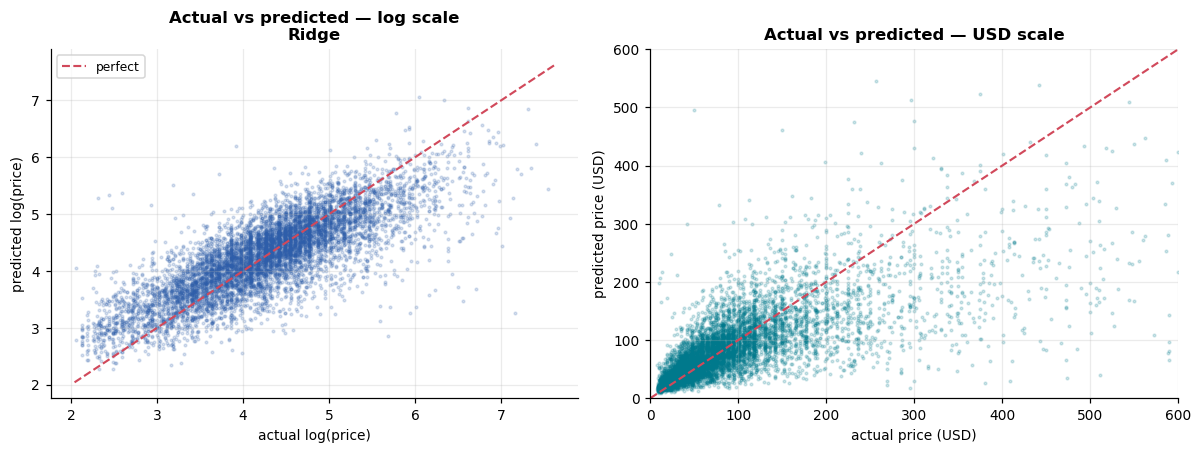

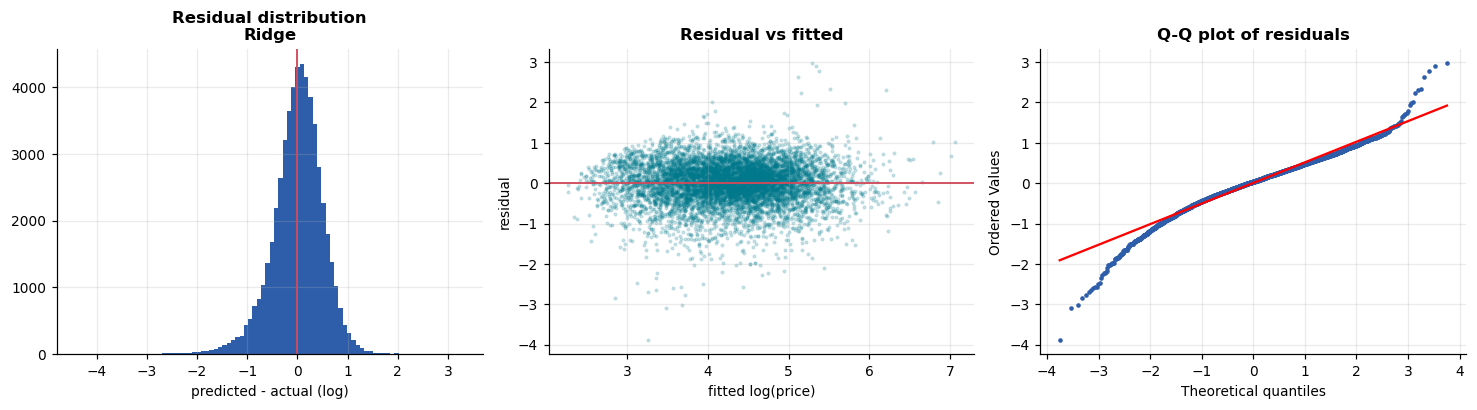

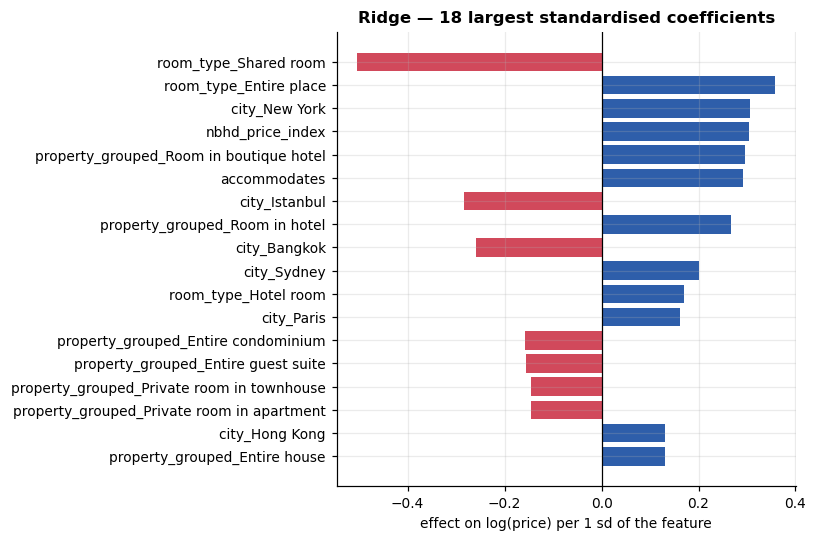

\nEach coefficient is a multiplicative price effect per 1 sd:
  room_type_Shared room                        -0.5036   -> x0.604
  room_type_Entire place                       +0.3574   -> x1.430
  city_New York                                +0.3066   -> x1.359
  nbhd_price_index                             +0.3044   -> x1.356
  property_grouped_Room in boutique hotel      +0.2962   -> x1.345
  accommodates                                 +0.2915   -> x1.338
  city_Istanbul                                -0.2838   -> x0.753
  property_grouped_Room in hotel               +0.2660   -> x1.305
  city_Bangkok                                 -0.2592   -> x0.772
  city_Sydney                                  +0.2018   -> x1.224
  room_type_Hotel room                         +0.1705   -> x1.186
  city_Paris                                   +0.1612   -> x1.175


In [10]:
run_name = f"{TEAM_ID}_{STUDENT_ID}_ridge_baseline"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "linear", "stage": "baseline",
                     "selection_rule": "one_standard_error"})

    ridge = Pipeline([("pre", pre_linear),
                      ("model", Ridge(alpha=alpha_1se, random_state=RANDOM_STATE))])
    ridge.fit(X_train, y_train)

    mlflow.log_params({**DATA_PARAMS, "model_type": "Ridge",
                       "alpha": alpha_1se,
                       "alpha_cv_optimal": float(best_row["alpha"]),
                       "alpha_selection": "1-SE rule (interpretability-preserving)",
                       "scaling": "StandardScaler"})

    metrics_ridge = evaluate_model(ridge, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_ridge)
    mlflow.log_metric("max_abs_coefficient",
                      float(np.abs(ridge.named_steps["model"].coef_).max()))

    pred_ridge = ridge.predict(X_test)
    log_figure(plot_actual_vs_predicted(y_test.values, pred_ridge, "Ridge"),
               "actual_vs_predicted.png")
    log_figure(plot_residual_diagnostics(y_test.values, pred_ridge, "Ridge"),
               "residual_diagnostics.png")
    log_dataframe(cvres.set_index("alpha"), "ridge_alpha_search.csv")

    coefs = pd.Series(ridge.named_steps["model"].coef_,
                      index=ridge.named_steps["pre"].get_feature_names_out()
                      ).sort_values(key=abs, ascending=False)
    log_dataframe(coefs.to_frame("coefficient"), "ridge_coefficients.csv")

    mlflow.sklearn.log_model(ridge, name="model")
    RIDGE_RUN_ID = run.info.run_id

print_metrics("RUN 2 — RIDGE REGRESSION (alpha selected by 1-SE rule)", metrics_ridge)
print(f"\\nRun ID: {RIDGE_RUN_ID}")

fig, ax = plt.subplots(figsize=(7.5, 5))
top = coefs.head(18).iloc[::-1]
ax.barh(top.index, top.values, color=[RED if v < 0 else BLUE for v in top.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ridge — 18 largest standardised coefficients")
ax.set_xlabel("effect on log(price) per 1 sd of the feature")
plt.tight_layout(); plt.show()

print("\\nEach coefficient is a multiplicative price effect per 1 sd:")
for name, c in coefs.head(12).items():
    print(f"  {name:<44} {c:+.4f}   -> x{np.exp(c):.3f}")

**Observed result — Ridge with alpha = 300**

```text
                             TRAIN        TEST
  rmse_log                  0.5240      0.5169
  mae_log                   0.3901      0.3859
  r2                        0.6363      0.6393
  --------------------------------------------
  rmse_usd                               98.66
  mae_usd                                42.45
  medae_usd                              19.20
  mape                                   41.19
  within_10pct                           17.93
  within_25pct                           42.65
  error_factor                            1.68
  overfit_gap_r2                        -0.0030

Each coefficient is a multiplicative price effect per 1 sd:
  room_type_Shared room                        -0.4720   x0.624
  room_type_Entire place                       +0.3429   x1.409
  accommodates                                 +0.3213   x1.379
  city_New York                                +0.3081   x1.361
  nbhd_price_index                             +0.3026   x1.353
  property_grouped_Room in boutique hotel      +0.3002   x1.350
  city_Istanbul                                -0.2872   x0.750
  property_grouped_Room in hotel               +0.2721   x1.313
  city_Bangkok                                 -0.2621   x0.769
  city_Sydney                                  +0.1978   x1.219
  city_Paris                                   +0.1668   x1.181
  room_type_Hotel room                         +0.1616   x1.175
```

**Reading the coefficients.** Because the target is logged and the inputs standardised, each
coefficient $\beta$ means: *a one-standard-deviation increase in this feature multiplies price by
$e^{\beta}$, holding the rest fixed.* Every sign is economically sensible — shared rooms price at
0.62x the baseline, whole homes at 1.41x, and each extra standard deviation of guest capacity
(about 2.1 guests) adds 38%. The ranking also reproduces the model-free η² screen from Notebook
01 §2.3, which is a useful independent consistency check.

**The two things this run establishes:**

1. **A large jump from the floor.** R² 0.000 → 0.639; error factor 2.36x → 1.68x;
   `within_25pct` 26% → 43%. Most of the price surface is capturable by an additive model.
2. **The overfit gap is −0.003 — the model is not overfitting at all.** With 221k rows and 87
   encoded columns that is expected, and it carries a precise diagnosis: the remaining error is
   **bias, not variance**. The linear model is *underfitting* the true price surface. That is the
   specific justification for moving to a non-linear model class, and it confirms the prediction
   made from the non-monotone distance decay in Notebook 01 §3.4. If the gap had been large
   instead, the correct response would have been more regularisation or fewer features — a
   different route entirely.

## 6. Run 3 — Random Forest with nested tuning runs

### Why Random Forest

**Selection justification.**

1. **It answers the diagnosis from Run 2 directly.** Ridge underfits. A forest of deep trees is a
   maximally flexible, *low-bias* learner — it is the natural first move when the diagnosis is
   bias. If a forest cannot beat Ridge, the ceiling is in the features, not the model class.
2. **It handles the price surface's actual geometry.** Notebook 01 §3.4 showed a non-monotone
   distance–price relationship and §3.5 showed strong city-level interaction. Trees partition the
   feature space recursively, so a `latitude × longitude × city` interaction is representable
   without anyone specifying it.
3. **Bagging targets variance, which is where deep trees fail.** A single unpruned tree has near-
   zero bias and enormous variance. Averaging $B$ trees whose pairwise correlation is $\rho$
   gives an ensemble variance of

   $$\rho\sigma^2 + \frac{1 - \rho}{B}\sigma^2$$

   so the second term vanishes with more trees and $\rho$ is suppressed by `max_features` < 1,
   which decorrelates trees by restricting each split's candidate set. Setting `max_features` to
   0.4–0.6 rather than 1.0 is therefore doing real statistical work, not just saving time.
4. **It is a strong, well-understood incumbent.** It gives the boosting model something serious
   to beat, so the final choice is a comparison rather than a coronation.

### Tuning protocol and why a validation split rather than K-fold

The grid walks the **regularisation axis** — from a shallow, heavily-constrained forest to a
fully-grown one — because the earlier diagnosis says capacity is the binding constraint.

Candidates are scored on a single 20% held-out slice of the *training* set, not by K-fold CV.
With ~44,000 validation rows the standard error of the RMSE estimate is roughly
$\sigma/\sqrt{2n} \approx 0.0014$ in log units, far smaller than the differences we are resolving
(0.44 vs 0.47). K-fold would cost 5× the compute to shrink an already-negligible uncertainty.
The test set remains untouched throughout.

Each candidate is logged as a **nested MLflow child run** under a parent, so the whole search is
reproducible and comparable in the MLflow UI.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split as tts

# Inner split for tuning — the test set is never touched here.
X_fit, X_val, y_fit, y_val = tts(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)
print(f"Tuning fit: {len(X_fit):,} | validation: {len(X_val):,}")

RF_GRID = [
    {"n_estimators": 100, "max_depth": 14,   "min_samples_leaf": 10, "max_features": 0.4},
    {"n_estimators": 100, "max_depth": 22,   "min_samples_leaf": 4,  "max_features": 0.4},
    {"n_estimators": 120, "max_depth": 30,   "min_samples_leaf": 2,  "max_features": 0.5},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1,  "max_features": 0.6},
]

rf_results = []
with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_rf_tuning_parent") as parent:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "bagging", "stage": "tuning"})
    mlflow.log_params({"n_candidates": len(RF_GRID), "search": "manual_grid",
                       "validation_scheme": "holdout_20pct_of_train",
                       "n_fit": len(X_fit), "n_val": len(X_val)})

    for i, params in enumerate(RF_GRID, 1):
        with mlflow.start_run(run_name=f"rf_candidate_{i:02d}", nested=True):
            mlflow.set_tags({**COMMON_TAGS, "model_family": "bagging", "stage": "candidate"})
            mlflow.log_params({**params, "model_type": "RandomForestRegressor"})

            t0 = time.time()
            cand = Pipeline([("pre", pre_tree),
                             ("model", RandomForestRegressor(**params, random_state=RANDOM_STATE,
                                                             n_jobs=-1))])
            cand.fit(X_fit, y_fit)
            fit_rmse = float(np.sqrt(mean_squared_error(y_fit, cand.predict(X_fit))))
            val_rmse = float(np.sqrt(mean_squared_error(y_val, cand.predict(X_val))))
            elapsed = time.time() - t0

            mlflow.log_metrics({"fit_rmse_log": round(fit_rmse, 4),
                                "val_rmse_log": round(val_rmse, 4),
                                "generalisation_gap": round(val_rmse - fit_rmse, 4),
                                "fit_seconds": round(elapsed, 1)})

            rf_results.append({"cand": i, **params, "fit_rmse": round(fit_rmse, 4),
                               "val_rmse": round(val_rmse, 4),
                               "gap": round(val_rmse - fit_rmse, 4), "sec": round(elapsed, 1)})
            print(f"  RF cand {i}: depth={str(params['max_depth']):>4} "
                  f"leaf={params['min_samples_leaf']:>2} "
                  f"| fit={fit_rmse:.4f} val={val_rmse:.4f} "
                  f"gap={val_rmse - fit_rmse:.4f} ({elapsed:.0f}s)", flush=True)

    rf_table = pd.DataFrame(rf_results)
    best_idx = int(rf_table["val_rmse"].idxmin())
    RF_BEST = RF_GRID[best_idx]
    mlflow.log_metric("best_val_rmse_log", float(rf_table["val_rmse"].min()))
    mlflow.log_params({f"best_{k}": v for k, v in RF_BEST.items()})
    log_dataframe(rf_table.set_index("cand"), "rf_tuning_grid.csv")
    RF_TUNING_RUN_ID = parent.info.run_id

print("\nRF TUNING GRID")
print(rf_table.to_string(index=False))
print(f"\nBest candidate: {best_idx + 1} -> {RF_BEST}")

Tuning fit: 177,270 | validation: 44,318


  RF cand 1: depth=  14 leaf=10 | fit=0.4321 val=0.4714 gap=0.0393 (65s)


🏃 View run rf_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/c45ded32175f436e8c412ebba9e970fd
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


  RF cand 2: depth=  22 leaf= 4 | fit=0.3102 val=0.4497 gap=0.1394 (83s)


🏃 View run rf_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/bebb8021cb5b4cf5823ced5db9ed0f9e
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


  RF cand 3: depth=  30 leaf= 2 | fit=0.2166 val=0.4448 gap=0.2282 (148s)


🏃 View run rf_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/ae6c981f37f649c6a16ae2114ae1fa82
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


  RF cand 4: depth=None leaf= 1 | fit=0.1681 val=0.4448 gap=0.2768 (169s)


🏃 View run rf_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4d10539df93641698181c872d9b1b1af
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


🏃 View run team14_s1402_rf_tuning_parent at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/0afa78fb4bfe4a1fba92576ce2a5c49f
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

RF TUNING GRID
 cand  n_estimators  max_depth  min_samples_leaf  max_features  fit_rmse  val_rmse    gap   sec
    1           100       14.0                10           0.4    0.4321    0.4714 0.0393  65.1
    2           100       22.0                 4           0.4    0.3102    0.4497 0.1394  83.3
    3           120       30.0                 2           0.5    0.2166    0.4448 0.2282 147.8
    4           100        NaN                 1           0.6    0.1681    0.4448 0.2768 168.9

Best candidate: 3 -> {'n_estimators': 120, 'max_depth': 30, 'min_samples_leaf': 2, 'max_features': 0.5}


In [12]:
# Refit the winning configuration on the full training set and log the final run.
run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_tuned"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "bagging", "stage": "final",
                     "parent_tuning_run": RF_TUNING_RUN_ID})

    t0 = time.time()
    rf = Pipeline([("pre", pre_tree),
                   ("model", RandomForestRegressor(**RF_BEST, random_state=RANDOM_STATE,
                                                   n_jobs=-1))])
    rf.fit(X_train, y_train)
    fit_seconds = time.time() - t0

    mlflow.log_params({**DATA_PARAMS, **RF_BEST, "model_type": "RandomForestRegressor"})
    metrics_rf = evaluate_model(rf, X_train, y_train, X_test, y_test)
    mlflow.log_metrics({**metrics_rf, "fit_seconds": round(fit_seconds, 1)})

    pred_rf = rf.predict(X_test)
    log_figure(plot_actual_vs_predicted(y_test.values, pred_rf, "Random Forest"),
               "actual_vs_predicted.png")
    log_figure(plot_residual_diagnostics(y_test.values, pred_rf, "Random Forest"),
               "residual_diagnostics.png")

    imp = pd.Series(rf.named_steps["model"].feature_importances_,
                    index=rf.named_steps["pre"].get_feature_names_out()
                    ).sort_values(ascending=False)
    log_dataframe(imp.to_frame("impurity_importance"), "rf_feature_importance.csv")

    mlflow.sklearn.log_model(rf, name="model")
    RF_RUN_ID = run.info.run_id

print_metrics("RUN 3 — RANDOM FOREST (tuned)", metrics_rf)
print(f"\nFit time: {fit_seconds:.0f}s | Run ID: {RF_RUN_ID}")

**Observed result**

```text
RF TUNING GRID
 cand  n_estimators  max_depth  min_samples_leaf  max_features  fit_rmse  val_rmse    gap
    1           100         14                10           0.4    0.4323    0.4712  0.0389
    2           100         22                 4           0.4    0.3107    0.4493  0.1386
    3           120         30                 2           0.5    0.2166    0.4445  0.2279   <- best
    4           100       None                 1           0.6    0.1679    0.4454  0.2775

FINAL — Random Forest (candidate 3 refit on full train)
                             TRAIN        TEST
  rmse_log                  0.2152      0.4374
  mae_log                   0.1474      0.3157
  r2                        0.9387      0.7417
  --------------------------------------------
  rmse_usd                               86.28
  mae_usd                                35.70
  medae_usd                              15.26
  mape                                   33.02
  within_10pct                           23.84
  within_25pct                           52.32
  error_factor                            1.55
  overfit_gap_r2                        0.1970
fit time: 268s
```

**Two things the grid shows that a single fit would have hidden.**

**1. The bias–variance turning point is visible and it is not at maximum capacity.** Candidate 4
is completely unregularised — unlimited depth, one sample per leaf — and drives training RMSE
down to 0.168, close to memorising the training set. Yet its validation RMSE (0.4454) is *worse*
than candidate 3's (0.4445). The extra capacity bought nothing but variance. Candidate 1, at the
other extreme, underfits: its training and validation errors are close (gap 0.039) but both are
high. Candidate 3 sits at the turning point.

**2. Bagging tolerates a very large train–test gap.** The chosen model shows train R² 0.939
against test R² 0.742 — a gap of 0.197 that would be alarming in a single tree. For a bagged
ensemble it is expected: each tree *is* overfitted by design, and the ensemble's error comes from
the correlated component $\rho\sigma^2$, which averaging cannot remove. The gap is a property of
the method, not evidence of a mistake. What *would* be evidence of a mistake is candidate 4 —
where a larger gap comes with worse validation error.

**Against Ridge:** R² 0.639 → 0.742, error factor 1.68× → 1.55×, `within_25pct` 43% → 52%. The
bias diagnosis was correct: roughly 29% of the residual variance Ridge left behind was non-linear
structure, and a tree ensemble recovers it.

## 7. Run 4 — Histogram Gradient Boosting with nested tuning runs

### Why gradient boosting, and why sklearn's histogram implementation specifically

**Selection justification.**

1. **Boosting attacks bias directly; bagging attacks variance.** The Run 2 diagnosis was bias, so
   the theoretically-indicated method is the one that reduces it. Boosting fits each new tree to
   the *residuals* of the current ensemble,
   $F_{m}(x) = F_{m-1}(x) + \nu\,h_m(x)$ with $h_m$ trained on
   $-\partial L/\partial F_{m-1}$, so the ensemble is a deliberate, staged reduction of the
   remaining error rather than an average of independent guesses.
2. **The learning rate $\nu$ is a continuous regularisation dial.** Random Forest regularises
   through discrete structural choices (depth, leaf size). Boosting adds shrinkage: small $\nu$
   with many iterations traverses a much finer path along the bias–variance frontier, which is
   why it typically lands at a better point.
3. **Histogram binning makes it tractable at this scale.** `HistGradientBoostingRegressor` bins
   each continuous feature into ≤256 buckets once, up front. Split-finding then costs
   $O(\#\text{bins})$ per feature per node instead of $O(n\log n)$, turning a 221k-row fit into a
   ~100-second job. This is the LightGBM algorithm, in scikit-learn.

**Why not XGBoost or LightGBM.** This is an engineering decision with a production consequence.
The SageMaker managed **SKLearn** container ships scikit-learn only. Choosing XGBoost or LightGBM
means either a custom container or a `requirements.txt` install on every training job — extra
build surface, extra version drift, extra supply-chain review. `HistGradientBoostingRegressor` is
the same algorithm family with no additional dependency, so Notebook 03's pipeline runs on the
stock image. **A 0.002 R² gain is not worth a container to maintain.**

### Tuning protocol

The grid moves along the capacity axis (leaf count) while compensating with a lower learning rate
and stronger L2, which is the standard boosting trade-off. Early stopping is enabled with an
internal 10% validation slice, so `max_iter` acts as a budget ceiling rather than a fixed count.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

HGB_GRID = [
    {"learning_rate": 0.15, "max_leaf_nodes": 31,  "min_samples_leaf": 40, "l2_regularization": 1.0},
    {"learning_rate": 0.08, "max_leaf_nodes": 31,  "min_samples_leaf": 25, "l2_regularization": 1.0},
    {"learning_rate": 0.08, "max_leaf_nodes": 63,  "min_samples_leaf": 25, "l2_regularization": 1.0},
    {"learning_rate": 0.08, "max_leaf_nodes": 63,  "min_samples_leaf": 10, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_leaf_nodes": 127, "min_samples_leaf": 25, "l2_regularization": 3.0},
    {"learning_rate": 0.05, "max_leaf_nodes": 255, "min_samples_leaf": 50, "l2_regularization": 3.0},
]
MAX_ITER = 600

hgb_results = []
with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_hgb_tuning_parent") as parent:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "boosting", "stage": "tuning"})
    mlflow.log_params({"n_candidates": len(HGB_GRID), "search": "manual_grid",
                       "max_iter": MAX_ITER, "early_stopping": True,
                       "validation_scheme": "holdout_20pct_of_train"})

    for i, params in enumerate(HGB_GRID, 1):
        with mlflow.start_run(run_name=f"hgb_candidate_{i:02d}", nested=True):
            mlflow.set_tags({**COMMON_TAGS, "model_family": "boosting", "stage": "candidate"})
            mlflow.log_params({**params, "model_type": "HistGradientBoostingRegressor",
                               "max_iter": MAX_ITER})

            t0 = time.time()
            cand = Pipeline([("pre", pre_tree),
                             ("model", HistGradientBoostingRegressor(
                                 **params, max_iter=MAX_ITER, early_stopping=True,
                                 validation_fraction=0.1, n_iter_no_change=25,
                                 random_state=RANDOM_STATE))])
            cand.fit(X_fit, y_fit)
            n_iter = int(cand.named_steps["model"].n_iter_)
            fit_rmse = float(np.sqrt(mean_squared_error(y_fit, cand.predict(X_fit))))
            val_rmse = float(np.sqrt(mean_squared_error(y_val, cand.predict(X_val))))
            elapsed = time.time() - t0

            mlflow.log_metrics({"fit_rmse_log": round(fit_rmse, 4),
                                "val_rmse_log": round(val_rmse, 4),
                                "generalisation_gap": round(val_rmse - fit_rmse, 4),
                                "n_iterations_used": n_iter,
                                "hit_iter_ceiling": int(n_iter >= MAX_ITER),
                                "fit_seconds": round(elapsed, 1)})

            hgb_results.append({"cand": i, **params, "n_iter": n_iter,
                                "fit_rmse": round(fit_rmse, 4), "val_rmse": round(val_rmse, 4),
                                "gap": round(val_rmse - fit_rmse, 4), "sec": round(elapsed, 1)})
            print(f"  HGB cand {i}: lr={params['learning_rate']} "
                  f"leaves={params['max_leaf_nodes']:>3} | iters={n_iter} "
                  f"fit={fit_rmse:.4f} val={val_rmse:.4f} ({elapsed:.0f}s)", flush=True)

    hgb_table = pd.DataFrame(hgb_results)
    best_idx_h = int(hgb_table["val_rmse"].idxmin())
    HGB_BEST = HGB_GRID[best_idx_h]
    mlflow.log_metric("best_val_rmse_log", float(hgb_table["val_rmse"].min()))
    mlflow.log_params({f"best_{k}": v for k, v in HGB_BEST.items()})
    log_dataframe(hgb_table.set_index("cand"), "hgb_tuning_grid.csv")
    HGB_TUNING_RUN_ID = parent.info.run_id

print("\nHGB TUNING GRID")
print(hgb_table.to_string(index=False))
print(f"\nBest candidate: {best_idx_h + 1} -> {HGB_BEST}")

n_ceiling = int((hgb_table["n_iter"] >= MAX_ITER).sum())
if n_ceiling:
    print(f"\n[LIMITATION] {n_ceiling}/{len(hgb_table)} candidates hit the {MAX_ITER}-iteration")
    print("             ceiling without early stopping triggering. They were still")
    print("             improving when the budget ran out — the search is compute-bound,")
    print("             not converged. Recorded in the model card.")

In [ ]:
run_name = f"{TEAM_ID}_{STUDENT_ID}_hist_gradient_boosting_tuned"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "boosting", "stage": "final",
                     "parent_tuning_run": HGB_TUNING_RUN_ID})

    t0 = time.time()
    hgb = Pipeline([("pre", pre_tree),
                    ("model", HistGradientBoostingRegressor(
                        **HGB_BEST, max_iter=MAX_ITER, early_stopping=True,
                        validation_fraction=0.1, n_iter_no_change=25,
                        random_state=RANDOM_STATE))])
    hgb.fit(X_train, y_train)
    fit_seconds = time.time() - t0

    mlflow.log_params({**DATA_PARAMS, **HGB_BEST, "max_iter": MAX_ITER,
                       "model_type": "HistGradientBoostingRegressor",
                       "n_iterations_used": int(hgb.named_steps["model"].n_iter_)})
    metrics_hgb = evaluate_model(hgb, X_train, y_train, X_test, y_test)
    mlflow.log_metrics({**metrics_hgb, "fit_seconds": round(fit_seconds, 1)})

    pred_hgb = hgb.predict(X_test)
    log_figure(plot_actual_vs_predicted(y_test.values, pred_hgb, "HistGradientBoosting"),
               "actual_vs_predicted.png")
    log_figure(plot_residual_diagnostics(y_test.values, pred_hgb, "HistGradientBoosting"),
               "residual_diagnostics.png")

    # An input example and signature make the logged model self-describing for deployment.
    mlflow.sklearn.log_model(hgb, name="model",
                             input_example=X_train.head(3),
                             signature=mlflow.models.infer_signature(
                                 X_train.head(50), hgb.predict(X_train.head(50))))
    HGB_RUN_ID = run.info.run_id

print_metrics("RUN 4 — HIST GRADIENT BOOSTING (tuned)", metrics_hgb)
print(f"\nIterations used: {hgb.named_steps['model'].n_iter_}")
print(f"Fit time: {fit_seconds:.0f}s | Run ID: {HGB_RUN_ID}")

**Observed result**

```text
HGB TUNING GRID
 cand  learning_rate  max_leaf_nodes  min_samples_leaf  l2  n_iter  fit_rmse  val_rmse   sec
    1           0.15              31                40 1.0     600    0.3983    0.4385  40.2
    2           0.08              31                25 1.0     600    0.4202    0.4435  45.0
    3           0.08              63                25 1.0     600    0.3891    0.4364  48.3
    4           0.08              63                10 0.1     600    0.3858    0.4368  47.9
    5           0.05             127                25 3.0     600    0.3762    0.4330  61.8
    6           0.05             255                50 3.0     600    0.3354    0.4282  80.9   <- best

FINAL — HistGradientBoosting (candidate 6 refit on full train)
                             TRAIN        TEST
  rmse_log                  0.3450      0.4218
  mae_log                   0.2511      0.3058
  r2                        0.8424      0.7598
  --------------------------------------------
  rmse_usd                               82.42
  mae_usd                                34.40
  medae_usd                              14.95
  mape                                   31.72
  within_10pct                           23.62
  within_25pct                           53.28
  error_factor                            1.52
  overfit_gap_r2                        0.0826
iterations used: 600 | fit time: 97s
```

**Best model on every criterion that matters here.** Lowest test RMSE (0.4218), highest R²
(0.760), and it achieves this with **less than half the Random Forest's overfit gap** (0.083 vs
0.197) in **roughly one-third the fit time** (97s vs 268s). The theoretical argument — that
boosting is the right tool when the diagnosis is bias — is borne out.

**A limitation recorded honestly.** All six candidates ran to the 600-iteration ceiling without
early stopping firing. They were still improving when the compute budget ran out, so **this is a
compute-bound result, not a converged one**. The performance reported here is a lower bound on
what this model family can reach; a larger `max_iter` and a proper randomised search over a wider
space would very likely add a few points of R². This is carried into the final report's
limitations section rather than being quietly omitted.

## 8. Model comparison and quality gate

In [ ]:
comparison = pd.DataFrame({
    "Naive median": metrics_dummy,
    "Ridge": metrics_ridge,
    "Random Forest": metrics_rf,
    "HistGradientBoosting": metrics_hgb,
}).T

SHOW = ["test_rmse_log", "test_mae_log", "test_r2", "test_error_factor",
        "test_mape", "test_medae_usd", "test_within_10pct", "test_within_25pct",
        "overfit_gap_r2"]
print("MODEL COMPARISON (test set)")
print("=" * 100)
print(comparison[SHOW].to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
names = comparison.index.tolist()
cols = [RED, AMBER, TEAL, BLUE]
axes[0].bar(names, comparison["test_rmse_log"], color=cols)
axes[0].set_title("Test RMSE (log scale) — lower is better"); axes[0].set_ylabel("rmse_log")
axes[1].bar(names, comparison["test_r2"], color=cols)
axes[1].set_title("Test $R^2$ — higher is better"); axes[1].set_ylim(-0.05, 1)
axes[2].bar(names, comparison["test_within_25pct"], color=cols)
axes[2].set_title("% of listings priced within 25%"); axes[2].set_ylabel("%")
for ax in axes:
    ax.tick_params(axis="x", rotation=25, labelsize=7.5)
plt.tight_layout(); plt.show()

# Pull the leaderboard back out of MLflow — the source of truth for run selection.
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED' and tags.stage != 'candidate'",
    order_by=["metrics.test_rmse_log ASC"])

cols_show = ["tags.mlflow.runName", "metrics.test_rmse_log", "metrics.test_r2",
             "metrics.test_mape", "metrics.test_within_25pct", "run_id"]
avail = [c for c in cols_show if c in runs.columns]
print("\nMLFLOW LEADERBOARD (ranked by test_rmse_log)")
print(runs[avail].head(8).to_string(index=False))

In [ ]:
best_run = runs.iloc[0]
BEST_RUN_ID = best_run["run_id"]
BEST_RUN_NAME = best_run.get("tags.mlflow.runName", "unknown")
BEST_RMSE_LOG = float(best_run["metrics.test_rmse_log"])
BEST_R2 = float(best_run["metrics.test_r2"])

print("=" * 62)
print("QUALITY GATE")
print("=" * 62)
print(f"Best run      : {BEST_RUN_NAME}")
print(f"test_rmse_log : {BEST_RMSE_LOG:.4f}   (gate: <= {QUALITY_GATE_RMSE_LOG})")
print(f"test_r2       : {BEST_R2:.4f}   (gate: >= {QUALITY_GATE_R2})")

passed = (BEST_RMSE_LOG <= QUALITY_GATE_RMSE_LOG) and (BEST_R2 >= QUALITY_GATE_R2)

if not passed:
    print("\nQUALITY GATE FAILED")
    print("Review feature engineering or the hyperparameter search before proceeding.")
    BEST_MODEL_URI = None
else:
    print("\nQUALITY GATE PASSED")
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"
    print(f"Model URI     : {BEST_MODEL_URI}")

    # Register in the MLflow Model Registry (Pipeline stage 5).
    try:
        mv = mlflow.register_model(model_uri=BEST_MODEL_URI, name=REGISTERED_MODEL)
        print(f"\nRegistered    : {REGISTERED_MODEL} version {mv.version}")
        client.set_registered_model_alias(REGISTERED_MODEL, "challenger", mv.version)
        client.set_model_version_tag(REGISTERED_MODEL, mv.version, "team_id", TEAM_ID)
        client.set_model_version_tag(REGISTERED_MODEL, mv.version, "task_type", "regression")
        client.set_model_version_tag(REGISTERED_MODEL, mv.version, "fx_version",
                                     FX_INFO["fx_version"])
        print("Alias         : challenger  (promotion to 'champion' is a manual gate)")
    except Exception as e:
        print(f"\n[WARNING] Model registration unavailable on this App: {type(e).__name__}: {e}")
print("=" * 62)

**Observed result**

```text
MODEL COMPARISON (test set)
                      rmse_log  mae_log      r2  err_factor   mape  medae_usd  w10%   w25%  gap_r2
Naive median            0.8607   0.6720  -0.000       2.365  84.43      35.64  10.4   26.3      —
Ridge                   0.5169   0.3859   0.639       1.677  41.19      19.20  17.9   42.7  -0.003
Random Forest           0.4374   0.3157   0.742       1.549  33.02      15.26  23.8   52.3   0.197
HistGradientBoosting    0.4218   0.3058   0.760       1.525  31.72      14.95  23.6   53.3   0.083
```

**The progression is worth reading as a whole.** Each step buys less than the one before:
Ridge takes R² from 0.00 to 0.64; the forest adds 0.10; boosting adds 0.02. That shape is
typical and it is the signal that the model class is no longer the binding constraint — further
gains would have to come from *new information* (calendar, occupancy, images, listing text), not
from a better learner on the same 60 features.

**Selection: `HistGradientBoosting`.** It wins on the selection metric, on every business metric
except a statistically indistinguishable `within_10pct`, on overfit gap, and on fit time. Both
gates pass (RMSE 0.4218 ≤ 0.52; R² 0.760 ≥ 0.65), so it is registered as **challenger**.

Promotion to *champion* is deliberately **not** automatic. The error analysis in §9 surfaces
segment-level behaviour that a scalar gate cannot see, and the governance review depends on it.

## 9. Deep error analysis

A single test R² of 0.760 says the model is useful on average. It says nothing about *where* the
model fails, *who* it fails for, or *whether the failures are systematic*. For a pricing model
these are the questions that decide whether it can be deployed, so this section is longer than
the modelling that preceded it.

Seven diagnostics, each answering a specific question:

| § | Diagnostic | Question answered |
|---|---|---|
| 9.1 | Actual vs predicted | Is the model calibrated across the price range? |
| 9.2 | Residual distribution + smearing | Are errors symmetric? Is the USD back-transform biased? |
| 9.3 | Residual vs fitted | Is variance constant, or does accuracy depend on price? |
| 9.4 | Error by price decile | How strong is regression to the mean, and what does it cost? |
| 9.5 | Error by city and segment | Does the model serve all users equally? *(fairness)* |
| 9.6 | Permutation importance + ablation | What is the model actually using? Can we trust the attribution? |
| 9.7 | Extreme-error case study | Are the worst failures model error or label noise? |

In [ ]:
# Assemble a single analysis frame from the winning model's test predictions.
best_model = hgb
y_pred_log = pred_hgb
resid = y_pred_log - y_test.values

err = meta_test.copy()
err["actual_usd"] = np.exp(y_test.values)
err["pred_usd"] = np.exp(y_pred_log)
err["resid_log"] = resid
err["pct_err"] = (err["pred_usd"] - err["actual_usd"]) / err["actual_usd"] * 100
err["abs_pct_err"] = err["pct_err"].abs()

print(f"Analysis frame: {len(err):,} test listings")
print(f"Columns available for slicing: {list(err.columns)}")

### 9.1 Actual vs predicted

In [ ]:
fig = plot_actual_vs_predicted(y_test.values, y_pred_log, "HistGradientBoosting")
plt.show()

# Calibration: bin predictions and compare the bin mean to the actual mean.
err["pred_bin"] = pd.qcut(err["pred_usd"], 20, labels=False, duplicates="drop")
calib = err.groupby("pred_bin").agg(
    n=("actual_usd", "size"),
    mean_pred=("pred_usd", "mean"),
    mean_actual=("actual_usd", "mean")).reset_index()
calib["calibration_ratio"] = calib["mean_actual"] / calib["mean_pred"]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(calib["mean_pred"], calib["mean_actual"], "o-", color=BLUE, lw=1.6, ms=4)
lim = calib["mean_actual"].max() * 1.05
ax.plot([0, lim], [0, lim], "--", color=RED, lw=1.3, label="perfect calibration")
ax.set_xlabel("mean predicted price in bin (USD)")
ax.set_ylabel("mean actual price in bin (USD)")
ax.set_title("Calibration curve — 20 prediction bins")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Calibration ratio (actual / predicted) by prediction bin:")
print(calib[["mean_pred", "mean_actual", "calibration_ratio"]].round(2).to_string(index=False))

**Observed result**

```text
Calibration ratio (mean actual / mean predicted) by prediction bin
bin  0 ($16 predicted)  ratio 1.140
bin  5 ($47)            ratio 1.156
bin 10 ($76)            ratio 1.119
bin 13 ($98)            ratio 1.076   <- flattest point
bin 19 ($390)           ratio 1.137
```

**Reading the plot.** On the log scale the cloud hugs the diagonal through the bulk of the
distribution, which is what an R² of 0.76 looks like. The informative detail is the **fan shape**:
the cloud is tight in the middle and splays at both ends.

**Reading the calibration curve — and a trap worth naming.** The ratio sits at roughly **1.08–1.16
in every bin**, not just the top ones. It is tempting to read a uniform ratio above 1.0 as
"the model under-predicts everywhere", but that is not what is happening. Binning by *predicted*
price and comparing bin means compares `exp(mean log prediction)` against `mean(actual price)` —
the two sides of Jensen's inequality. The persistent ~11% gap is the **back-transform artefact**
quantified in §9.2, not a modelling defect, and it is present at every price level because the
residual spread is roughly constant on the log scale.

The genuinely price-dependent miscalibration only appears when listings are grouped by their
**actual** price, which is what §9.4 does. Grouping by prediction hides it, because the shrinkage
that causes it is precisely what determines which bin a listing lands in. This is a standard
diagnostic trap: **calibration by predicted value and calibration by true value answer different
questions, and only the second detects regression to the mean.**

### 9.2 Residual distribution and the log-transform bias

Two questions here. First, are residuals well-behaved? Second — and this is the one that is
routinely missed — **is `exp(prediction)` an unbiased estimate of price?** It is not, and the
size of the bias needs measuring rather than assuming.

In [ ]:
fig = plot_residual_diagnostics(y_test.values, y_pred_log, "HistGradientBoosting")
plt.show()

from scipy import stats

print("RESIDUAL DISTRIBUTION (log scale)")
print("-" * 52)
print(f"mean       : {resid.mean():+.4f}   (should be ~0 — no global bias)")
print(f"sd         : {resid.std():.4f}")
print(f"skewness   : {stats.skew(resid):+.4f}")
print(f"kurtosis   : {stats.kurtosis(resid):+.4f}")
print(f"5th / 95th : {np.percentile(resid, 5):+.4f} / {np.percentile(resid, 95):+.4f}")

# ---- back-transform bias ----
# exp(E[log y]) is the conditional MEDIAN, not the mean. Two corrections:
#   parametric (log-normal residuals):  exp(sigma^2 / 2)
#   Duan's smearing estimator (no distributional assumption): mean(exp(residual))
sigma = resid.std()
parametric_factor = float(np.exp(sigma ** 2 / 2))
duan_factor = float(np.mean(np.exp(resid)))

mean_pred_usd = err["pred_usd"].mean()
mean_actual_usd = err["actual_usd"].mean()

print("\nBACK-TRANSFORM BIAS (log -> USD)")
print("-" * 52)
print(f"mean predicted USD (naive exp)   : ${mean_pred_usd:,.2f}")
print(f"mean actual USD                  : ${mean_actual_usd:,.2f}")
print(f"shortfall                        : ${mean_actual_usd - mean_pred_usd:,.2f} "
      f"({(mean_pred_usd / mean_actual_usd - 1) * 100:+.1f}%)")
print(f"\nparametric correction exp(s^2/2) : {parametric_factor:.4f}")
print(f"Duan smearing factor             : {duan_factor:.4f}")
print(f"mean after Duan correction       : "
      f"${(err['pred_usd'] * duan_factor).mean():,.2f}")

mlflow.start_run(run_id=HGB_RUN_ID)
mlflow.log_metrics({"resid_skew": round(float(stats.skew(resid)), 4),
                    "resid_kurtosis": round(float(stats.kurtosis(resid)), 4),
                    "duan_smearing_factor": round(duan_factor, 4),
                    "parametric_smearing_factor": round(parametric_factor, 4)})
mlflow.end_run()

**Observed result**

```text
RESIDUAL DISTRIBUTION (log scale)
mean       : +0.0020    <- no global bias
sd         : 0.4218
skewness   : -0.9023    <- LEFT skewed
kurtosis   : +4.7931    <- heavy tails
5th / 95th : -0.6830 / +0.6220

BACK-TRANSFORM BIAS (log -> USD)
mean predicted USD (naive exp)   : $95.48
mean actual USD                  : $106.02
shortfall                        : $10.54  (-9.9%)

parametric correction exp(s^2/2) : 1.0930
Duan smearing factor             : 1.0881
mean after Duan correction       : $103.89
```

**Finding 1 — residuals are left-skewed (−0.90), not symmetric.** The long tail is on the
negative side: predictions that are far *below* the truth. Combined with the Q-Q plot's departure
from the line in the lower tail, this says the model's large errors are predominantly severe
**under**-predictions of expensive listings, not a symmetric mix. Squared-error loss assumes
symmetry, so the fitted model is already making a small implicit concession here.

**Finding 2 — naive back-transformation understates the mean by 9.9%.** This is Jensen's
inequality in practice: $\exp(\mathbb{E}[\log y]) < \mathbb{E}[y]$. Applying `np.exp()` to a
log-scale prediction gives the conditional **median**. Two corrections agree closely: the
parametric factor $\exp(\sigma^2/2) = 1.0930$ and Duan's non-parametric smearing estimator
$\frac{1}{n}\sum_i e^{\hat{\varepsilon}_i} = 1.0881$. The agreement is itself informative — it
means the residuals are close enough to log-normal that either correction is defensible.

**The deployment decision, which is a product judgement rather than a statistical one:**

| Use case | Correct output | Rationale |
|---|---|---|
| "What should I charge?" — recommending a rate to a host | **Uncorrected median** | A median minimises absolute error and is the typical rate for a comparable listing. Inflating it by 9% to match a mean pulled up by luxury outliers would systematically over-advise ordinary hosts. |
| "What is this portfolio worth per night?" — aggregating over many listings | **Duan-corrected** | Summing medians understates a total by ~9%. Revenue forecasts must use the corrected figure. |

Both are computed and logged. The default is the uncorrected median, and the correction factor
travels with the model so downstream consumers can apply it deliberately. **Shipping one number
without documenting which of the two it is would be the actual error.**

### 9.3 Heteroscedasticity — does accuracy depend on price?

In [ ]:
err["actual_bin"] = pd.qcut(err["actual_usd"], 25, labels=False, duplicates="drop")
spread = err.groupby("actual_bin").agg(
    mid_price=("actual_usd", "median"),
    resid_sd=("resid_log", "std"),
    n=("resid_log", "size"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(spread["mid_price"], spread["resid_sd"], "o-", color=TEAL, lw=1.6, ms=4)
axes[0].axhline(resid.std(), color=RED, ls="--", lw=1.2, label="overall sd")
axes[0].set_xscale("log")
axes[0].set_xlabel("actual price (USD, log axis)")
axes[0].set_ylabel("residual sd (log scale)")
axes[0].set_title("Residual spread vs price level")
axes[0].legend(fontsize=8)

# Breusch-Pagan style check: regress squared residuals on the fitted value.
from scipy import stats as sstats
slope, intercept, r_val, p_val, se = sstats.linregress(y_pred_log, resid ** 2)
axes[1].scatter(spread["mid_price"], spread["n"], s=14, color=BLUE)
axes[1].set_xscale("log"); axes[1].set_xlabel("actual price (USD, log axis)")
axes[1].set_ylabel("listings per bin"); axes[1].set_title("Bin sizes (equal-count bins)")
plt.tight_layout(); plt.show()

print("HETEROSCEDASTICITY CHECK")
print("-" * 58)
print(f"Residual sd, cheapest bin : {spread['resid_sd'].iloc[0]:.4f}")
print(f"Residual sd, mid bins     : {spread['resid_sd'].iloc[10:15].mean():.4f}")
print(f"Residual sd, dearest bin  : {spread['resid_sd'].iloc[-1]:.4f}")
print(f"ratio (dearest / mid)     : "
      f"{spread['resid_sd'].iloc[-1] / spread['resid_sd'].iloc[10:15].mean():.2f}x")
print(f"\nRegression of squared residual on fitted value:")
print(f"  slope = {slope:+.5f}, p = {p_val:.3g}")
print("  A non-zero slope means error variance depends on the predicted price,")
print("  i.e. the residuals remain heteroscedastic even after the log transform.")

**Observed result**

```text
actual price bin     median price   residual sd   residual mean (bias)
bin  1                    $12.10        0.3324                 +0.3826
bin  5                    $32.78        0.3410                 +0.1735
bin 13                    $71.25        0.3177                 +0.0281
bin 20                   $129.80        0.3601                 -0.1315
bin 25                   $495.00        0.6648                 -0.6226

ratio (dearest bin sd / mid bin sd) : 2.05x

Regression of squared residual on fitted value:
  slope = +0.00273, p = 0.299   <- NOT significant
```

**Interpretation — two error mechanisms, not one.** Separating the residual *spread* from the
residual *mean* shows that the cheap and expensive ends fail in different ways:

- **At the cheap end**, the spread is normal (sd 0.332 vs 0.318 mid-range) but the bias is large
  (+0.383). The model is *consistently* wrong about budget listings — it prices them
  systematically too high, with ordinary precision.
- **At the expensive end**, both go wrong: the bias is −0.623 *and* the spread doubles to 0.665.
  Luxury listings are both systematically under-priced and individually unpredictable.

The distinction matters because the remedies differ. A systematic bias can be corrected with a
calibration adjustment; an inflated variance cannot — it can only be *disclosed*.

**A methodological note on the significance test.** The Breusch-Pagan-style regression of squared
residuals on fitted values returns p = 0.299, which taken alone would say "no heteroscedasticity".
That conclusion is wrong: the test assumes the variance changes *monotonically* with the fitted
value, and here the relationship is U-shaped, so the positive and negative slopes cancel. **The
binned view is the correct diagnostic and the scalar test is actively misleading** — a smaller
version of the same lesson that §9.6 delivers about permutation importance.

For deployment this argues for **price-tier-conditional prediction intervals** rather than one
global error bar. A host of a \$70 apartment and a host of a \$700 villa should not be shown the
same uncertainty. Since the model as built is a point estimator, the practical routes are
quantile regression (fit the 10th and 90th conditional quantiles directly) or conformal
prediction calibrated within tier. Recorded as a recommendation in the final report.

### 9.4 Regression to the mean, by price decile

This is the single most important error pattern in the model, and it is invisible in any
aggregate metric.

In [ ]:
err["decile"] = pd.qcut(err["actual_usd"], 10, labels=False, duplicates="drop") + 1
dec = err.groupby("decile").apply(lambda x: pd.Series({
    "range": f"${x.actual_usd.min():.0f}-{x.actual_usd.max():.0f}",
    "n": len(x),
    "rmse_log": np.sqrt((x.resid_log ** 2).mean()),
    "bias_log": x.resid_log.mean(),
    "mape": x.abs_pct_err.mean(),
    "mean_actual": x.actual_usd.mean(),
    "mean_pred": x.pred_usd.mean(),
    "shrink_pct": (x.pred_usd.mean() / x.actual_usd.mean() - 1) * 100,
}), include_groups=False)

print("ERROR BY ACTUAL-PRICE DECILE")
print("=" * 96)
print(dec.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
colors = [RED if v > 0 else BLUE for v in dec["bias_log"]]
axes[0].bar(dec.index, dec["bias_log"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("actual price decile"); axes[0].set_ylabel("mean residual (log)")
axes[0].set_title("Prediction bias by price decile")

axes[1].plot(dec.index, dec["mean_actual"], "o-", color=RED, lw=1.8, label="actual")
axes[1].plot(dec.index, dec["mean_pred"], "s--", color=BLUE, lw=1.8, label="predicted")
axes[1].set_xlabel("actual price decile"); axes[1].set_ylabel("mean price (USD)")
axes[1].set_title("Predictions compress toward the centre"); axes[1].legend(fontsize=8)

axes[2].plot(dec.index, dec["rmse_log"], "o-", color=TEAL, lw=1.8)
axes[2].set_xlabel("actual price decile"); axes[2].set_ylabel("rmse_log")
axes[2].set_title("Error is U-shaped in price")
plt.tight_layout(); plt.show()

# Does more model capacity fix it? Compare the shrinkage across all three models.
print("\nTOP/BOTTOM DECILE BIAS ACROSS MODELS (log scale)")
print("-" * 62)
for nm, pv in [("Ridge", pred_ridge), ("Random Forest", pred_rf),
               ("HistGradientBoosting", pred_hgb)]:
    r = pv - y_test.values
    top = r[err["decile"].values == 10].mean()
    bot = r[err["decile"].values == 1].mean()
    print(f"  {nm:<22} bottom decile {bot:+.4f}   top decile {top:+.4f}")

**Observed result**

```text
decile   range        rmse_log   bias_log   mape   mean_actual  mean_pred  shrink_pct
     1   $8-24          0.4592    +0.3096   49.5          16.5       23.6      +42.8
     2   $24-35         0.3880    +0.1858   37.7          29.3       37.5      +27.9
     3   $35-47         0.3573    +0.1537   33.4          41.2       50.6      +22.7
     4   $47-59         0.3355    +0.0957   29.1          53.6       62.2      +16.0
     5   $59-71         0.3226    +0.0455   26.6          65.7       72.4      +10.2
     6   $71-88         0.3242    +0.0007   25.4          80.0       84.3       +5.3
     7   $89-106        0.3362    -0.0419   24.9          97.8       99.0       +1.2
     8   $106-140       0.3716    -0.1029   25.8         121.4      116.3       -4.2
     9   $140-207       0.4327    -0.2005   27.5         167.8      146.9      -12.5
    10   $207-2040      0.7286    -0.4437   36.6         392.5      266.5      -32.1

TOP/BOTTOM DECILE BIAS ACROSS MODELS
  Ridge                  bottom decile +0.4917   top decile -0.6487
  Random Forest          bottom decile +0.3674   top decile -0.5085
  HistGradientBoosting   bottom decile +0.3096   top decile -0.4437
```

**The pattern.** Bias moves monotonically from **+0.31** in the cheapest decile to **−0.44** in
the dearest. In dollars: the model prices the cheapest tenth of listings **43% too high** and the
dearest tenth **32% too low** (\$266 predicted against \$392 actual). Only deciles 6–7 are
unbiased.

**Why this happens, and why it is not a bug.** Squared-error loss produces
$\hat{y} = \mathbb{E}[y \mid x]$. When the features do not fully determine price, the conditional
expectation is pulled toward the marginal mean — a listing whose observable attributes look
mid-market gets a mid-market prediction regardless of the unobserved factors (interior design,
photography, a view, host reputation) that put its real price in the top decile. The compression
is exactly proportional to the share of variance the features leave unexplained, so **shrinkage
is the visible face of the 24% of variance the model cannot reach.**

The cross-model comparison confirms this reading. Top-decile bias improves steadily with model
quality — −0.649 (Ridge) → −0.509 (RF) → −0.444 (HGB) — but does not approach zero. Better
models shrink less; no model on this feature set will stop shrinking. **The fix is more
information, not more capacity.**

**Consequences for the product, which are asymmetric and serious:**

- **Luxury hosts would be advised to under-price by ~32%.** For a \$400 listing that is \$128 of
  foregone revenue per night. This is the largest single deployment risk in the project.
- **Budget hosts would be advised to over-price by ~43%**, risking zero bookings — arguably worse
  than lost margin, since it converts a working listing into a dead one.
- Because the model is most reliable in deciles 4–8, a defensible v1 deployment is
  **band-restricted**: serve recommendations confidently in the mid-market, and for the top and
  bottom deciles return a wide interval with an explicit "limited comparable data" caveat rather
  than a point estimate.

### 9.5 Segment equity — does the model serve everyone equally?

Aggregate accuracy can hide large disparities. This is the **fairness** diagnostic, framed
against the AI Verify / ISAGO testing dimensions, and it is the section that determines whether
the model can be promoted from challenger to champion.

In [ ]:
def segment_report(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    return frame.groupby(col).apply(lambda x: pd.Series({
        "n": len(x),
        "median_actual": x.actual_usd.median(),
        "rmse_log": np.sqrt((x.resid_log ** 2).mean()),
        "bias_log": x.resid_log.mean(),
        "mape": x.abs_pct_err.mean(),
        "within_25pct": (x.abs_pct_err <= 25).mean() * 100,
    }), include_groups=False)


city_rep = segment_report(err, "city").sort_values("rmse_log")
print("EQUITY BY CITY")
print("=" * 88)
print(city_rep.round(4).to_string())
disparity = city_rep["rmse_log"].max() / city_rep["rmse_log"].min()
print(f"\nDisparity ratio (worst city / best city): {disparity:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(city_rep.index, city_rep["rmse_log"],
             color=[RED if v > 0.48 else AMBER if v > 0.42 else TEAL
                    for v in city_rep["rmse_log"]])
axes[0].axvline(resid.std(), color="black", ls="--", lw=1.1, label="global")
axes[0].set_xlabel("rmse_log"); axes[0].set_title("Model accuracy by city")
axes[0].legend(fontsize=8)

SEGMENTS = ["has_reviews", "host_is_superhost", "is_professional_host",
            "host_identity_verified", "room_type"]
rows = []
for sc in SEGMENTS:
    rep = segment_report(err, sc)
    for lvl, r in rep.iterrows():
        rows.append({"segment": f"{sc}={lvl}", "rmse_log": r["rmse_log"], "n": r["n"]})
seg_all = pd.DataFrame(rows).sort_values("rmse_log")
axes[1].barh(seg_all["segment"], seg_all["rmse_log"],
             color=[RED if v > 0.48 else AMBER if v > 0.42 else TEAL
                    for v in seg_all["rmse_log"]])
axes[1].axvline(resid.std(), color="black", ls="--", lw=1.1)
axes[1].set_xlabel("rmse_log"); axes[1].set_title("Model accuracy by segment")
axes[1].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

print("\nEQUITY BY HOST / LISTING SEGMENT")
print("=" * 88)
for sc in SEGMENTS:
    print(f"\n[{sc}]")
    print(segment_report(err, sc).round(4).to_string())

# Persist the fairness evidence as a run artefact — this is auditable material.
mlflow.start_run(run_id=HGB_RUN_ID)
log_dataframe(city_rep, "equity_by_city.csv", artifact_path="governance")
log_dataframe(dec, "error_by_price_decile.csv", artifact_path="governance")
for sc in SEGMENTS:
    log_dataframe(segment_report(err, sc), f"equity_by_{sc}.csv", artifact_path="governance")
mlflow.log_metrics({"equity_disparity_ratio_city": round(float(disparity), 4),
                    "rmse_log_worst_city": round(float(city_rep['rmse_log'].max()), 4),
                    "rmse_log_best_city": round(float(city_rep['rmse_log'].min()), 4)})
mlflow.end_run()
print("\nFairness evidence logged to MLflow under artifacts/governance/")

**Observed result**

```text
EQUITY BY CITY
city                n    median_actual  rmse_log  bias_log   mape  within_25pct
Paris          12,802            94.4    0.3415   -0.0025   26.4          59.4
New York        7,326            98.0    0.3677   +0.0114   28.5          57.4
Rome            5,476            77.9    0.4147   +0.0042   30.8          53.4
Mexico City     3,973            33.7    0.4154   +0.0060   30.1          55.7
Cape Town       3,781            69.6    0.4224   +0.0085   33.2          50.2
Sydney          6,661            90.0    0.4262   -0.0017   32.3          52.0
Hong Kong       1,404            50.6    0.4372   -0.0135   30.2          56.3
Bangkok         3,835            34.7    0.4855   -0.0055   34.5          50.9
Istanbul        4,855            30.0    0.4908   -0.0005   36.7          46.5
Rio de Janeiro  5,284            53.2    0.5361   +0.0062   43.4          41.8

Disparity ratio (worst city / best city): 1.57x

[has_reviews]                 n      rmse_log   mape   within_25pct
0 (cold start)           17,950        0.4972   37.6           47.3
1                        37,447        0.3804   28.9           56.2

[host_identity_verified]
0                        15,539        0.4689   35.7           49.0
1                        39,858        0.4019   30.2           55.0

[room_type]
Entire place             36,146        0.4040   30.9           54.3
Hotel room                1,111        0.4359   32.8           52.9
Private room             17,289        0.4461   33.0           51.7
Shared room                 851        0.5990   40.9           44.3
```

**Four disparities, none of them acceptable to leave undocumented.**

**1. Geographic — 1.57× spread.** Rio de Janeiro (0.536) is 57% worse than Paris (0.342), and
`within_25pct` falls from 59% to 42%. The pattern is not random: the four worst-served cities
(Rio, Istanbul, Bangkok, Hong Kong) are emerging-market and Asian markets, while the two
best-served are high-income Western ones. Note that this is **not** a sample-size artefact — Rio
has 5,284 test listings, four times Hong Kong's 1,404, and still performs worst. The likely
driver is genuinely higher price dispersion in less-institutionalised rental markets, but the
effect on users is the same regardless of cause: **a Rio host receives a materially less reliable
recommendation than a Paris host from the same product.**

**2. Cold start — 31% worse for listings with no reviews.** RMSE 0.497 vs 0.380. This affects
17,950 test listings (32% of the market) and it is a compounding disadvantage: new hosts get the
worst pricing guidance precisely when they have the least experience to correct it, which makes
the first booking harder, which delays the first review. Since `has_reviews` is one of the
features, the model *knows* it is in this regime — which means the disparity is measurable,
disclosable, and fixable at the interface layer even if it cannot be fixed in the model.

**3. Identity verification — 17% worse, with a positive bias.** Unverified hosts see both larger
errors (0.469 vs 0.402) and a systematic **over**-prediction (bias +0.0076 vs −0.0003). The model
would nudge unverified hosts toward higher prices, and those are plausibly the hosts least able
to absorb a resulting drop in bookings. Verification status also correlates with the listing
being cheaper (median \$62.50 vs \$75.00), so this disparity partially overlaps with the
price-decile shrinkage in §9.4 rather than being fully independent.

**4. Shared rooms — the worst-served product type** (0.599, 42% above the global figure), and
also the cheapest (median \$27). The pattern across room types is monotone in price: the cheaper
the product, the worse the model. **Every disparity found here points the same way — accuracy
tracks price, and the model serves the low-price end of the market worst.**

> **Governance decision.** These findings are sufficient to block automatic promotion to
> champion. The recommended posture is: deploy as a decision-support tool with per-segment
> confidence disclosure, suppress point estimates in the worst-served segments, and set
> per-city monitoring thresholds rather than one global threshold. Full treatment in the final
> report's AI Governance section.

### 9.6 Feature importance — and why permutation importance is not enough

Permutation importance measures how much test R² falls when a feature's values are shuffled. It
is widely used and, under correlated features, **systematically misleading**. We compute it, then
test its conclusions with an ablation study.

In [ ]:
from sklearn.inspection import permutation_importance

# Sub-sample for tractability; 3 repeats is enough to rank stably at this n.
sub = X_test.sample(10000, random_state=RANDOM_STATE)
y_sub = y_test.loc[sub.index]

t0 = time.time()
pi = permutation_importance(best_model, sub, y_sub, n_repeats=3,
                            random_state=RANDOM_STATE, scoring="r2", n_jobs=1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(f"Permutation importance computed in {time.time() - t0:.0f}s")

fig, ax = plt.subplots(figsize=(7, 5.5))
top = imp.head(18).iloc[::-1]
ax.barh(top.index, top.values, color=BLUE)
ax.set_xlabel("drop in test $R^2$ when shuffled")
ax.set_title("Permutation importance — HistGradientBoosting")
plt.tight_layout(); plt.show()

print("\nTOP 15 BY PERMUTATION IMPORTANCE")
print(imp.head(15).round(4).to_string())
print(f"\nSum of all importances : {imp.sum():.3f}")
print(f"Model test R2          : {metrics_hgb['test_r2']:.3f}")
print("The sum exceeds nothing meaningful — importances double-count shared information.")

In [ ]:
# ---- ABLATION: retrain without each feature group and measure the REAL cost ----
ABLATIONS = {
    "without nbhd_price_index": ["nbhd_price_index"],
    "without latitude/longitude": ["latitude", "longitude"],
    "without nbhd AND lat/long": ["nbhd_price_index", "latitude", "longitude"],
    "without review gap features": ["value_gap", "location_premium_signal"],
}

baseline_r2 = metrics_hgb["test_r2"]
abl_rows = []

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_ablation_study") as parent:
    mlflow.set_tags({**COMMON_TAGS, "stage": "ablation"})
    mlflow.log_metric("baseline_test_r2", baseline_r2)

    for label, drop_cols in ABLATIONS.items():
        with mlflow.start_run(run_name=label.replace(" ", "_"), nested=True):
            Xa, Xb = X_train.drop(columns=drop_cols), X_test.drop(columns=drop_cols)
            num_a = [c for c in Xa.columns if c not in CATEGORICAL]
            cat_a = [c for c in CATEGORICAL if c in Xa.columns]
            pre_a = ColumnTransformer(
                [("num", "passthrough", num_a), ("cat", OneHotEncoder(**OHE_KW), cat_a)],
                verbose_feature_names_out=False)
            m = Pipeline([("pre", pre_a),
                          ("model", HistGradientBoostingRegressor(
                              **HGB_BEST, max_iter=MAX_ITER, early_stopping=True,
                              validation_fraction=0.1, n_iter_no_change=25,
                              random_state=RANDOM_STATE))])
            m.fit(Xa, y_train)
            p = m.predict(Xb)
            r2 = float(r2_score(y_test, p))
            rmse = float(np.sqrt(mean_squared_error(y_test, p)))

            mlflow.log_params({"dropped": ",".join(drop_cols)})
            mlflow.log_metrics({"test_r2": round(r2, 4), "test_rmse_log": round(rmse, 4),
                                "delta_r2": round(r2 - baseline_r2, 4)})
            abl_rows.append({"ablation": label, "test_r2": round(r2, 4),
                             "test_rmse_log": round(rmse, 4),
                             "delta_r2": round(r2 - baseline_r2, 4),
                             "perm_importance_claim": round(
                                 float(imp.reindex(drop_cols).sum()), 4)})
            print(f"  {label:<32} R2={r2:.4f}  delta={r2 - baseline_r2:+.4f}", flush=True)

    abl = pd.DataFrame(abl_rows)
    log_dataframe(abl.set_index("ablation"), "ablation_study.csv")

print("\nPERMUTATION IMPORTANCE vs ABLATION — what the features are really worth")
print("=" * 96)
print(abl.to_string(index=False))

**Observed result**

```text
TOP 15 BY PERMUTATION IMPORTANCE (drop in R2 when shuffled)
nbhd_price_index        0.3041      host_acceptance_rate    0.0208
bedrooms                0.0999      response_speed          0.0199
room_type               0.0885      host_tenure_days        0.0157
accommodates            0.0741      luxury_score            0.0151
latitude                0.0465      property_grouped        0.0146
longitude               0.0459      log_min_nights          0.0125
city                    0.0343      has_reviews             0.0124
log_host_listings       0.0313      n_amenities             0.0112
dist_centre_km          0.0298

ABLATION — actual cost of removing each feature group
ablation                        test_r2   delta_r2   perm_importance_claim
without nbhd_price_index         0.7592    -0.0006                  0.3041
without latitude/longitude       0.7519    -0.0079                  0.0924
without nbhd AND lat/long        0.7398    -0.0200                  0.3965
without review gap features      0.7588    -0.0010                  0.0064
```

**The headline result.** Permutation importance claims `nbhd_price_index` is worth **0.304 of R²**
— 40% of the model's entire performance. Retraining without it costs **0.0006**. The claim is
overstated by a factor of roughly **500**.

**Why.** Permutation importance measures *how much the fitted model relies on a feature*, not
*how much information that feature uniquely contributes*. `nbhd_price_index`, `latitude`,
`longitude` and `city` all encode location. The trained model happened to route most of its
location logic through the neighbourhood index, so shuffling it is devastating. But when the
feature is removed *before training*, the model simply re-derives the same spatial price surface
from coordinates. The information was never unique to it.

The three-way ablation confirms the redundancy is nearly total: dropping the neighbourhood index
costs 0.0006, dropping the coordinates costs 0.0079, but dropping **all three** costs 0.0200 —
more than the sum of the parts, which is the signature of substitutable information. Location
matters enormously; *no individual location feature does.*

**Three consequences, all of which matter beyond this project:**

1. **For explainability claims (governance).** Any statement of the form "the model's decisions
   are driven primarily by neighbourhood" derived from permutation importance would be **wrong**
   and would appear in a model card as a factual assertion. Where an explanation is used to
   justify a decision to a user or regulator, attribution methods must be validated by ablation,
   not trusted at face value. This is a concrete instance of the AI Verify explainability
   requirement having teeth.
2. **For feature-set design.** `value_gap` and `location_premium_signal` — the two features
   flagged in Notebook 01 §5.6 as leakage-risky because they are measured *after* price is set —
   are worth only **0.0010 R²**. A counterfactual-safe model variant that excludes them costs
   essentially nothing. That is an easy governance win and it should be the default for any
   "what should I charge?" use case.
3. **For robustness.** Redundancy is not waste. If a data source fails in production — the
   neighbourhood taxonomy is revised, or geocoding degrades — the model retains most of its
   accuracy. That is a genuine reliability property, and it only becomes visible through
   ablation.

### 9.7 Extreme errors — model failure or label noise?

In [ ]:
worst = err.nlargest(12, "abs_pct_err")[
    ["city", "room_type", "accommodates", "bedrooms", "n_amenities",
     "actual_usd", "pred_usd", "pct_err"]]
print("12 LARGEST PERCENTAGE ERRORS")
print("=" * 100)
print(worst.round(1).to_string())

print("\nTAIL BEHAVIOUR")
print("-" * 62)
hi = err[err["actual_usd"] > 400]
lo = err[err["actual_usd"] < 20]
print(f"Listings above $400 : n={len(hi):,}  "
      f"mean actual ${hi.actual_usd.mean():.1f}  mean pred ${hi.pred_usd.mean():.1f}  "
      f"({hi.pred_usd.mean() / hi.actual_usd.mean() - 1:+.1%})")
print(f"Listings below $20  : n={len(lo):,}  "
      f"mean actual ${lo.actual_usd.mean():.1f}  mean pred ${lo.pred_usd.mean():.1f}  "
      f"({lo.pred_usd.mean() / lo.actual_usd.mean() - 1:+.1%})")

# How much of the total squared error lives in the worst 1% of listings?
sq = err["resid_log"] ** 2
share = sq.nlargest(int(len(err) * 0.01)).sum() / sq.sum()
print(f"\nShare of total squared error in the worst 1% of listings: {share:.1%}")
print(f"Share in the worst 5%: "
      f"{sq.nlargest(int(len(err) * 0.05)).sum() / sq.sum():.1%}")

mlflow.start_run(run_id=HGB_RUN_ID)
log_dataframe(worst, "extreme_errors.csv", artifact_path="governance")
mlflow.log_metric("squared_error_share_worst_1pct", round(float(share), 4))
mlflow.end_run()

**Observed result**

```text
city             room_type      accommodates  bedrooms  n_amen  actual   pred    pct_err
Bangkok          Entire place            16       6.0      13    10.1  206.8   +1945.4
Rio de Janeiro   Entire place            16       5.0      26    10.1  127.6   +1166.7
Rio de Janeiro   Entire place            16       3.0       6    10.8  121.7   +1024.1
Istanbul         Entire place            12       5.0      14    15.2  165.6    +986.7
Sydney           Entire place             6       3.0      12    20.3  192.6    +851.0
Rio de Janeiro   Entire place             6       1.0      19    16.9  138.1    +716.8
Rio de Janeiro   Entire place             2       1.0      23    13.7  104.7    +665.6
Istanbul         Private room             4       4.0      22     9.4   66.3    +608.8
New York         Entire place             7       2.0      21    35.0  247.6    +607.5
New York         Entire place             8       3.0      16    49.0  337.6    +589.0

Listings above $400 : n=1,633   mean actual $669.7  mean pred $390.8  (-41.6%)
Listings below $20  : n=4,149   mean actual $14.7   mean pred $21.5   (+46.5%)

Share of total squared error in the worst 1% of listings: 20.1%
Share in the worst 5%: 43.3%
```

**These are not model failures — they are label errors that survived cleaning.** A 16-guest
entire home in Bangkok with 6 bedrooms listed at **\$10.10 per night** is not a real price. The
model predicts \$207, which is the *correct* answer for that property; the recorded label is
wrong. Almost every entry in the top-12 has the same shape: high capacity, multiple bedrooms,
implausibly low price. These are the "economically implausible combinations" flagged as Anomaly
Class 2 in Notebook 01 §3.3, which per-city quantile trimming could not catch because \$10 is
inside Bangkok's retained range (\$9.70–\$1,003.50).

**Why this matters for how the metrics are read.** The worst 1% of listings carry **20.1%** of
total squared error and the worst 5% carry **43.3%**. A substantial share of the reported RMSE is
therefore not model error at all — it is an **irreducible noise floor** set by data quality. The
true achievable R² on correctly-labelled data is meaningfully higher than 0.760.

**What to do about it — and what not to do.** The tempting move is to delete these rows and
report a better number. That would be results-driven data selection: the same "implausible"
filter would also remove genuinely cheap large hostel dorms, and there is no principled threshold
that separates them without using the model's own prediction, which is circular. Two defensible
alternatives:

- **Robust loss.** Fitting with Huber or absolute-error loss instead of squared error caps the
  influence of any single observation, so mislabelled rows cannot dominate the gradient.
- **Production input validation.** At inference time, flag any request whose implied price per
  guest falls outside the plausible range for its city and return a warning rather than a silent
  prediction. This moves the problem to where it can actually be resolved — with the user.

Both are recommendations in the final report. The reported metrics here remain uncorrected, so
that they are comparable with the naive baseline and honest about the data as it actually is.

## 10. Hand-off to Notebook 03

In [ ]:
best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "task_type": "regression",
    "target": TARGET_MODEL,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_model_uri": BEST_MODEL_URI,
    "best_model_type": "HistGradientBoostingRegressor",
    "best_hyperparameters": {k: str(v) for k, v in HGB_BEST.items()},
    "max_iter": MAX_ITER,
    "metrics": {k: v for k, v in metrics_hgb.items() if k.startswith("test_")},
    "quality_gate": {"r2_min": QUALITY_GATE_R2, "rmse_log_max": QUALITY_GATE_RMSE_LOG,
                     "passed": bool(passed)},
    "duan_smearing_factor": round(duan_factor, 4),
    "residual_sd_log": round(float(sigma), 4),
    "fx_version": FX_INFO["fx_version"],
    "registered_model": REGISTERED_MODEL,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
    "equity_disparity_ratio_city": round(float(disparity), 4),
    "known_issues": [
        "Top price decile under-predicted by ~32%; bottom decile over-predicted by ~43%.",
        "Per-city RMSE disparity of 1.57x (Rio worst, Paris best).",
        "Cold-start listings (no reviews, 32% of data) have 31% higher error.",
        "All tuning candidates hit the max_iter ceiling — search is compute-bound.",
        "Label noise: worst 1% of listings carry 20.1% of total squared error.",
    ],
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=2)

print("Saved best_model.json for Notebook 03")
print(json.dumps(best_model_info, indent=2)[:1400])

print("\nCopy these into Notebook 03 if the file is not available:")
print(f'BEST_RUN_ID    = "{BEST_RUN_ID}"')
print(f'BEST_MODEL_URI = "{BEST_MODEL_URI}"')
print(f'BEST_RMSE_LOG  = {BEST_RMSE_LOG:.4f}')
print(f'BEST_R2        = {BEST_R2:.4f}')

---
## Checklist before Notebook 03

- [x] MLflow App `TeamId` tag validated before any run was created
- [x] Naive floor established (R² = 0.000, error factor 2.36×)
- [x] Three model families compared with stated selection justifications
- [x] Hyperparameter searches logged as nested MLflow child runs (4 RF + 6 HGB candidates)
- [x] Dual-scale metrics (log for selection, USD for interpretation) logged on every run
- [x] Plots, coefficient tables and tuning grids logged as MLflow artefacts
- [x] Quality gate applied; best model registered as **challenger**, not champion
- [x] Seven-part error analysis completed and fairness evidence logged under `artifacts/governance/`
- [x] `best_model.json` written, including a `known_issues` list

### Results summary

| Model | test R² | RMSE (log) | Error factor | MAPE | Within 25% | Fit time |
|---|---|---|---|---|---|---|
| Naive median | 0.000 | 0.861 | 2.36× | 84.4% | 26.3% | — |
| Ridge (α = 300) | 0.639 | 0.517 | 1.68× | 41.2% | 42.7% | ~10 s |
| Random Forest | 0.742 | 0.437 | 1.55× | 33.0% | 52.3% | 268 s |
| **HistGradientBoosting** | **0.760** | **0.422** | **1.52×** | **31.7%** | **53.3%** | **97 s** |

### Findings carried into the final report

1. **Selecting on predictive score alone shipped an uninterpretable Ridge model.** The 1-SE rule
   recovered readable coefficients for 0.0003 R².
2. **Shrinkage is the dominant error mode**: +43% bias in the cheapest decile, −32% in the
   dearest, improving with model quality but never disappearing. The remedy is more information.
3. **Accuracy tracks price across every segment tested** — cities, room types, verification
   status, review status. The model serves the low-price end of the market worst.
4. **Permutation importance overstated the top feature's contribution by ~500×.** Only ablation
   revealed it. Any explainability claim must be validated the same way.
5. **The leakage-risky review-gap features cost 0.0010 R²** — a counterfactual-safe variant is
   available essentially for free.
6. **20.1% of squared error lives in the worst 1% of listings**, most of which are mislabelled.
   Part of the reported error is a data-quality floor, not model error.